<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=329283118" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is overvalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import json
import torch
import requests
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime, timedelta
from sklearn import linear_model, preprocessing
from kaggle_secrets import UserSecretsClient
from IPython.display import HTML

In [2]:
# A GPU will be used, if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.]) cpu


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [3]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain a significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [4]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers = tickers.sort_values(by=['cik','ticker']).drop_duplicates(subset=['cik'],keep='first').set_index('cik')
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [5]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv',
                     index_col=['date','ticker'],
                     date_format='ISO8601',
                    ).replace({0.0:np.nan}).dropna()
prices.index.rename(['snapshot','ticker'],inplace=True)
prices

,,exchange,price
snapshot,ticker,,
2010-02-01,A,NYSE - Delayed Quote,20.05
2010-03-01,A,NYSE - Delayed Quote,22.50
2010-04-01,A,NYSE - Delayed Quote,24.60
2010-05-01,A,NYSE - Delayed Quote,25.94
2010-06-01,A,NYSE - Delayed Quote,23.15
...,...,...,...
2026-01-01,ZYME,NasdaqGS - Delayed Quote,26.33
2026-02-01,ZYME,NasdaqGS - Delayed Quote,22.53
2026-03-01,ZYME,NasdaqGS - Delayed Quote,23.29


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages here on Kaggle

In [6]:
keys = ['snapshot','cik','ticker','date']
snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',
                        index_col=keys,
                        usecols=keys+ml_features,
                        date_format='ISO8601',
                        dtype={'cik':str})

# We can only use ciks with a ticker symbol, because the prices dataset is per-ticker.
snapshots = snapshots[snapshots.index.get_level_values('ticker').notna()]

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].index.get_level_values('cik').unique().tolist()
snapshots = snapshots[~snapshots.index.isin(zero_asset_ciks,level='cik')]

# We ensure a window_size number of snapshots of historic data is available for each cik.
ciks_with_history = snapshots.reset_index(level='snapshot').groupby('cik')['snapshot'].count()
ciks_with_history = ciks_with_history[ciks_with_history >= window_size].index.unique().tolist()
snapshots = snapshots[snapshots.index.isin(ciks_with_history, level='cik')]

snapshots = pd.merge(snapshots, prices.drop(columns='exchange'), left_index=True, right_index=True, how='left')
snapshots

Assets  Liabilities  \
snapshot   cik        ticker date                                 
2013-01-01 0000001750 AIR    2012-11-30   2.189300     1.286500   
           0000001800 ABT    2012-09-30  63.257738    36.243563   
           0000002098 ACU    2012-09-30   0.067661     0.037283   
           0000002488 AMD    2012-09-29   4.612000     3.623000   
           0000002809 AEM    2012-09-30   5.218625     1.828573   
...                                            ...          ...   
2026-06-20 0001952073 MSGE   2026-03-31   1.957273     1.909268   
           0001953366 STHO   2026-03-31   0.480355     0.241466   
           0001955520 KNF    2026-03-31   3.817863     2.258538   
           0001958086 CLB    2026-03-31   0.587728     0.318842   
           0001964333 BHRB   2026-03-31   7.927711     7.063207   

                                         NetCashOperating_ttm  price  
snapshot   cik        ticker date                                     
2013-01-01 0000001750 AIR    2012-11-30              0.149717  18.68  
           0000001800 ABT    2012-09-30              9.212610  31.43  
           0000002098 ACU    2012-09-30              0.001128  11.04  
           0000002488 AMD    2012-09-29              0.135000   2.40  
           0000002809 AEM    2012-09-30              0.722071  52.46  
...                                                       ...    ...  
2026-06-20 0001952073 MSGE   2026-03-31              0.341042    NaN  
           0001953366 STHO   2026-03-31             -0.013730    NaN  
           0001955520 KNF    2026-03-31              0.345202    NaN  
           0001958086 CLB    2026-03-31              0.034336    NaN  
           0001964333 BHRB   2026-03-31              0.096788    NaN  

[475927 rows x 4 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in the new column *is_created* whether a row was artificially created or not.

In [7]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(
    len(unique_snapshot_dates), len(unique_ciks), len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),
                       ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.set_index(['cik','snapshot']).sort_index().drop(columns=['date','ticker'])
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df.info()

There are 160 unique snapshots and 3252 unique ciks for a total of 520320 records.
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 520320 entries, ('0000001750', Timestamp('2013-01-01 00:00:00')) to ('0001964333', Timestamp('2026-04-01 00:00:00'))
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Assets                520320 non-null  float64
 1   Liabilities           520320 non-null  float64
 2   NetCashOperating_ttm  520320 non-null  float64
 3   price                 520320 non-null  float64
 4   is_created            520320 non-null  bool   
dtypes: bool(1), float64(4)
memory usage: 18.5+ MB


The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Google's Gemini AI we re-created it to handle our multi-dimensional data.

Gemini states that: "Cosine similarity is equivalent to Pearson correlation only if the input vectors are first centered (mean is zero)". There is a quite nice CosineSimilarity class in PyTorch, so we extend it to fit our needs for a custom loss function.

From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (component market_assets_loss)

In [8]:
class MyPearsonLoss(torch.nn.CosineSimilarity):
    def forward(self, x1, x2, assets, asmul):
        
        pearson = super().forward(x1 - x1.mean(dim=self.dim, keepdim=True),
                                  x2 - x2.mean(dim=self.dim, keepdim=True))

        # If pearson = -1 -> corr = 2 (worst case)
        # If pearson =  0 -> corr = 1 (bad case)
        # If pearson =  1 -> corr = 0 (best case)
        corr = 1 - pearson

        self.correlation_loss = corr.sum() + corr.std()
        
        # The market as a whole does not adjust the total assets away from their nominal value:
        adjusted_assets = assets * 10**asmul.unsqueeze(1)
        self.market_assets_loss = (adjusted_assets.sum(dim=0) / assets.sum(dim=0) - 1).abs().sum()
        
        # We need some kind of regularization for the asset_multiplier,
        # otherwise the values become erratic and uncomparable across ciks
        self.asmul_loss = 10 * asmul.mean().abs() + asmul.std()
        
        # The total loss is just a weighted sum of the individual loss components
        total_loss = self.correlation_loss + self.market_assets_loss + 10 * self.asmul_loss
        
        return total_loss
        
    def get_param_state(self):
        """ Return a dictionary with the individual loss components """
        return { i:getattr(self,i).item() for i in dir(self) if '_loss' in i }

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. The model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates well with the price, it is not equal to the price.

In [9]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self, df, print_shape=True):
        super().__init__()
        self.print_shape = print_shape
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.ciks        = df.index.get_level_values(0).unique()
        self.len_ciks    = len(self.ciks)
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        if self.print_shape:
            print('Input shape:',self.ml_input.shape)
            print('Labels shape:',self.labels.shape)
            print('Asset multiplier shape:',self.asmul.shape)
            print('Cash multiplier shape:',self.cashmul.shape)
    
    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        adjusted_assets   = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul.unsqueeze(1)
        liabilities       = self.ml_input[:,:,self.columns['Liabilities']]
        adjusted_cashflow = self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        fwd = adjusted_assets - liabilities + adjusted_cashflow
        if self.print_shape:
            print('Adjusted assets shape:', adjusted_assets.shape)     
            print('Adjusted cashflow shape:', adjusted_cashflow.shape)     
            print('Forward shape:', fwd.shape)
            self.print_shape = False
        return fwd

    def get_df(self):
        asmul = pd.Series(index=self.ciks, data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(self.df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

pricing_model = SimplePricingModel(ml_input_df).to(device)
pricing_model.ml_input.device

Input shape: torch.Size([3252, 160, 3])
Labels shape: torch.Size([3252, 160])
Asset multiplier shape: torch.Size([3252])
Cash multiplier shape: torch.Size([160])


device(type='cpu')

Adjusted assets shape: torch.Size([3252, 160])
Adjusted cashflow shape: torch.Size([3252, 160])
Forward shape: torch.Size([3252, 160])
Epoch [1000/6000], Loss=938.68439306
Epoch [2000/6000], Loss=937.55219188
Epoch [3000/6000], Loss=937.29745941
Epoch [4000/6000], Loss=937.24446620
Epoch [5000/6000], Loss=937.09586216
Epoch [6000/6000], Loss=937.23026532


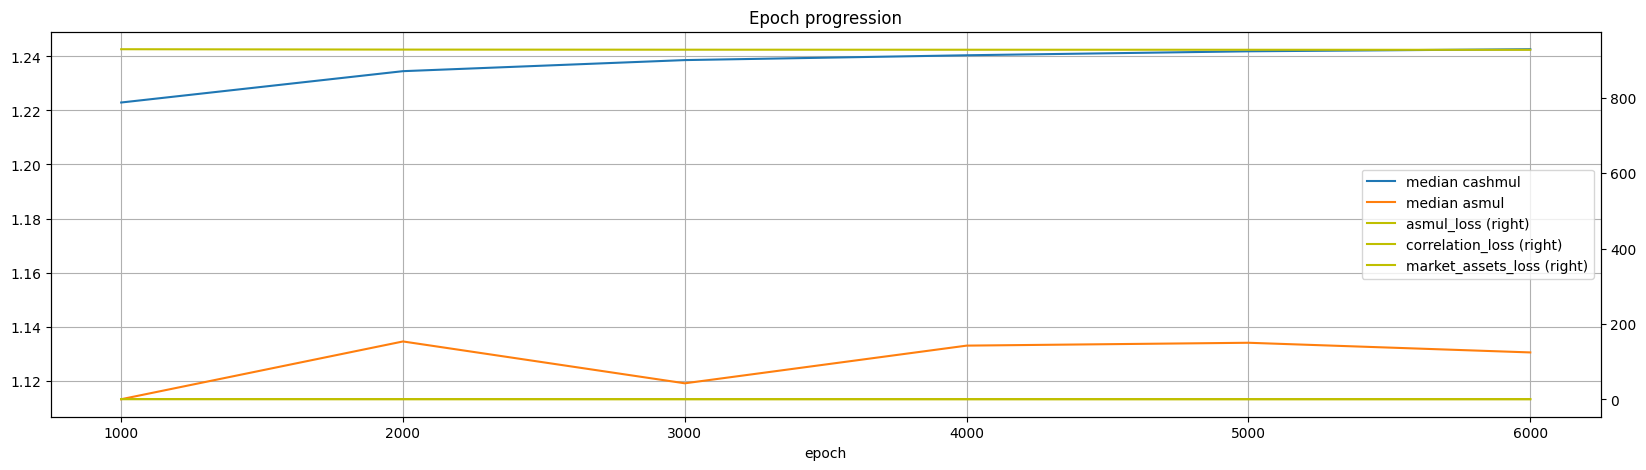

,median cashmul,median asmul,asmul_loss,correlation_loss,market_assets_loss
epoch,,,,,
1000,1.222939,1.113134,0.880112,928.735982,1.147295
2000,1.234536,1.134510,0.892245,927.768659,0.861080
3000,1.238635,1.119025,0.904848,927.472893,0.776082
4000,1.240420,1.132968,0.913323,927.382626,0.728612
5000,1.241889,1.134027,0.910820,927.300090,0.687575
6000,1.242658,1.130452,0.934888,927.153220,0.728162


In [10]:
def model_train(model, num_epochs = 6000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.2)
    loss_function = MyPearsonLoss()

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        y_pred = model.forward()
        loss = loss_function(y_pred, model.labels,
                             model.ml_input[:,:,model.columns['Assets']],
                             model.asmul)
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = { 'epoch':epoch+1, **model.get_param_state(), **loss_function.get_param_state() }
            output_graphic.append(param_state)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss={loss.item():.8f}")

    output_graphic = pd.DataFrame(output_graphic).set_index('epoch')
    loss_cols = [ a_col for a_col in output_graphic.columns if 'loss' in str(a_col) ]
    output_graphic.drop(columns=loss_cols).plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    for a_loss_col in loss_cols:
        output_graphic[a_loss_col].plot(secondary_y=True,legend=True,grid=False,c='y')
    plt.show()
    return output_graphic

model_train(pricing_model)

In [11]:
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                         
0000001750 2013-01-01  2.189300     1.286500              0.149717  18.68   
           2013-02-01  2.189300     1.286500              0.149717  18.85   
           2013-03-01  2.189300     1.286500              0.149717  17.57   
           2013-04-01  2.217000     1.293000              0.163817  18.39   
           2013-05-01  2.217000     1.293000              0.163817  17.86   
...                         ...          ...                   ...    ...   
0001964333 2025-12-01  7.889037     7.066806              0.153871  65.24   
           2026-01-01  7.889037     7.066806              0.153871  62.31   
           2026-02-01  7.889037     7.066806              0.153871  65.48   
           2026-03-01  7.920626     7.065977              0.107933  64.44   
           2026-04-01  7.920626     7.065977              0.107933  62.29   

                          asmul   cashmul     model  
cik        snapshot                                  
0000001750 2013-01-01  1.022577 -1.387064  0.744562  
           2013-02-01  1.022577 -1.092618  0.788645  
           2013-03-01  1.022577 -0.983974  0.804911  
           2013-04-01  1.022577 -0.796138  0.843633  
           2013-05-01  1.022577 -0.757155  0.850019  
...                         ...       ...       ...  
0001964333 2025-12-01  1.366854  1.484585  3.944794  
           2026-01-01  1.366854  1.504680  3.947886  
           2026-02-01  1.366854  1.674419  3.974004  
           2026-03-01  1.366854  1.735398  3.947672  
           2026-04-01  1.366854  1.544843  3.927105  

[396817 rows x 7 columns]

In [12]:
%%time
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,
                  model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),
                  left_index=True, right_index=True, how='left')

# The asset and cash multipliers are not available for the most recent snapshots,
# which are not part of the stock prices dataset.
# We use their latest available values in the model price formula for these recent snapshots. 
result = pd.concat([result.drop(columns=mul_columns),
                    result[mul_columns].groupby('cik',group_keys=False).apply(lambda x:x.interpolate())],
                   axis='columns')

result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']

# The model values and the prices correlate by design, so the simplest linear regression will yield
# a conversion between them.
def line_fit(df):
    regressor = linear_model.LinearRegression().fit(X=df['model'].to_frame(), y=df[ml_label])
    return pd.Series({'hype':regressor.coef_[0], 'bias':regressor.intercept_})

result = result.merge(result[['model',ml_label]].dropna().groupby(by=['ticker','cik']).apply(line_fit),
                     left_index=True, right_index=True, how='inner')

result['model_price'] = result['model'] * result['hype'] + result['bias']

result

CPU times: user 12.8 s, sys: 121 ms, total: 12.9 s
Wall time: 12.8 s


Assets  Liabilities  \
snapshot   cik        ticker date                                 
2013-01-01 0000001750 AIR    2012-11-30   2.189300     1.286500   
           0000001800 ABT    2012-09-30  63.257738    36.243563   
           0000002098 ACU    2012-09-30   0.067661     0.037283   
           0000002488 AMD    2012-09-29   4.612000     3.623000   
           0000002809 AEM    2012-09-30   5.218625     1.828573   
...                                            ...          ...   
2026-06-20 0001952073 MSGE   2026-03-31   1.957273     1.909268   
           0001953366 STHO   2026-03-31   0.480355     0.241466   
           0001955520 KNF    2026-03-31   3.817863     2.258538   
           0001958086 CLB    2026-03-31   0.587728     0.318842   
           0001964333 BHRB   2026-03-31   7.927711     7.063207   

                                         NetCashOperating_ttm  price  \
snapshot   cik        ticker date                                      
2013-01-01 0000001750 AIR    2012-11-30              0.149717  18.68   
           0000001800 ABT    2012-09-30              9.212610  31.43   
           0000002098 ACU    2012-09-30              0.001128  11.04   
           0000002488 AMD    2012-09-29              0.135000   2.40   
           0000002809 AEM    2012-09-30              0.722071  52.46   
...                                                       ...    ...   
2026-06-20 0001952073 MSGE   2026-03-31              0.341042    NaN   
           0001953366 STHO   2026-03-31             -0.013730    NaN   
           0001955520 KNF    2026-03-31              0.345202    NaN   
           0001958086 CLB    2026-03-31              0.034336    NaN   
           0001964333 BHRB   2026-03-31              0.096788    NaN   

                                            asmul   cashmul      model  \
snapshot   cik        ticker date                                        
2013-01-01 0000001750 AIR    2012-11-30  1.022577 -1.387064   0.744562   
           0000001800 ABT    2012-09-30  0.985233 -1.387064  13.301550   
           0000002098 ACU    2012-09-30  0.979414 -1.387064   0.027421   
           0000002488 AMD    2012-09-29  0.211281 -1.387064  -2.835825   
           0000002809 AEM    2012-09-30  0.443125 -1.387064  -0.517629   
...                                           ...       ...        ...   
2026-06-20 0001952073 MSGE   2026-03-31  1.306564  1.544843   1.174890   
           0001953366 STHO   2026-03-31  1.039456  1.544843   0.236631   
           0001955520 KNF    2026-03-31  0.743291  1.544843   1.112530   
           0001958086 CLB    2026-03-31  1.790609  1.544843   0.786593   
           0001964333 BHRB   2026-03-31  1.366854  1.544843   3.922342   

                                               hype       bias  model_price  
snapshot   cik        ticker date                                            
2013-01-01 0000001750 AIR    2012-11-30  100.738906 -66.836169     8.170157  
           0000001800 ABT    2012-09-30    2.277036  -6.056112    24.232002  
           0000002098 ACU    2012-09-30  270.089229   7.386246    14.792229  
           0000002488 AMD    2012-09-29   12.830255  50.143961    13.759602  
           0000002809 AEM    2012-09-30   26.133474  25.831476    12.304026  
...                                             ...        ...          ...  
2026-06-20 0001952073 MSGE   2026-03-31   54.335028   6.744260    70.581951  
           0001953366 STHO   2026-03-31   22.499571   2.569819     7.893922  
           0001955520 KNF    2026-03-31   61.731004  17.388597    86.066200  
           0001958086 CLB    2026-03-31  -40.964954  48.889687    16.666944  
           0001964333 BHRB   2026-03-31    3.051313  50.378010    62.346302  

[428707 rows x 10 columns]

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

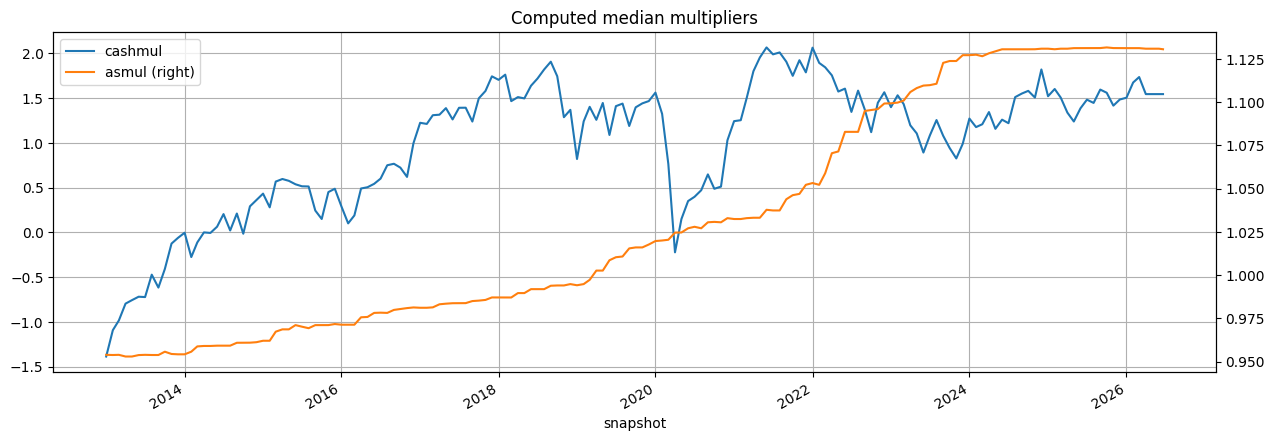

Median asset_multiplier per cik: 1.1307713985443115
Median asset_multiplier per snapshot: 1.0159651041030884


In [13]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['cashmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['asmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

Let's examine the distribution of the achieved correlations:

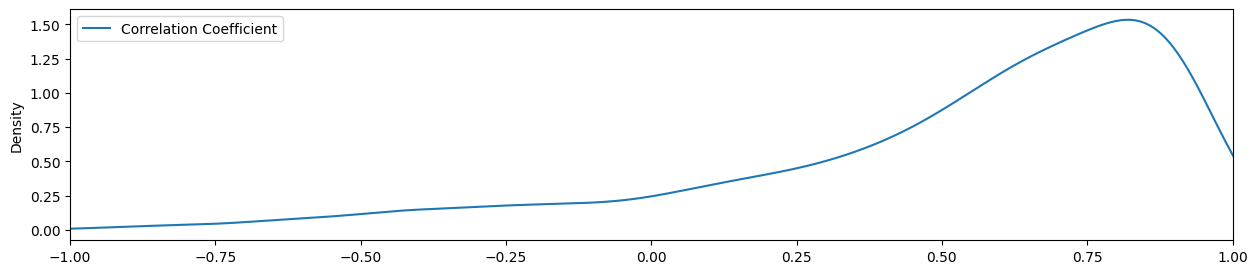

In [14]:
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().unstack().sum(axis='columns')/2 - 1
model_corr = model_corr.rename('Correlation Coefficient').to_frame()
model_corr.plot.density(bw_method=0.2,figsize=(15,3),xlim=(-1,1))
plt.show()

In [15]:
# Reality check for our fair price calculations:
# compute their correlation with the actual prices
result[['price','model_price']].dropna().corr()

,price,model_price
price,1.000000,0.900285
model_price,0.900285,1.000000


The [Monthly US Stock Prices](https://www.kaggle.com/datasets/vladosht/monthly-us-stock-prices) dataset is updated a few times annually, which means the stock prices used in this notebook are quite outdated most of the time. Here we attempt to obtain delayed, but still recent prices. This is not reliable, as it uses a free online service. If it works though, the plots below will be more up-to-date.

In [16]:
def get_dataframe_from_api(endpoint):
    r = requests.get(api_url.format(endpoint))
    r.raise_for_status()
    return pd.DataFrame(r.json())[['dateStamp','code','name','close','volume','change']]

try:
    api_url = UserSecretsClient().get_secret("api_url")
    api_data = pd.concat([get_dataframe_from_api(exchange) for exchange in ['NASDAQ','NYSE']])
except:
    api_data = None
    print('Failed to fetch recent prices.')

In [17]:
if api_data is not None:
    recent_prices = api_data.rename(columns={'dateStamp':'snapshot','close':'price'})
    recent_prices['ticker'] = recent_prices['code'].astype(str).str.upper().str.strip()
    recent_prices = recent_prices[recent_prices['ticker'].isin(result.index.get_level_values('ticker').unique())]
    recent_prices = recent_prices.sort_values(['ticker','snapshot']).drop_duplicates(subset=['ticker'],keep='last')
    recent_prices = recent_prices[(recent_prices['price']>0.005)&(recent_prices['volume']>0)&(recent_prices['change'].abs()>0.0)]
    recent_prices = recent_prices[recent_prices['snapshot'] == recent_prices['snapshot'].value_counts().index[0]]
    recent_prices = recent_prices[['snapshot','ticker','price','name']].set_index('ticker')

We will use a scaled ratio of model price to actual price as an overvaluation metric.

In [18]:
%%time
def compute_overvaluation(df):
    ticker = df.index.get_level_values('ticker').unique()[0]
    try:
        df.iloc[-1,df.columns.get_loc('price')] = recent_prices.loc[ticker]['price']
    except:
        pass
    df['overvaluation'] = df['model_price'] / df['price']
    df['overvaluation'] = -1 * preprocessing.RobustScaler().fit_transform(df['overvaluation'].to_frame())
    return df
result = result.groupby('cik',group_keys=False).apply(compute_overvaluation)

CPU times: user 13.6 s, sys: 82.6 ms, total: 13.7 s
Wall time: 13.7 s


In [19]:
# Display a sample before the CSV export
result[result.index.isin([min(result.index.get_level_values('cik'))],level='cik')]

,,,,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,ticker,date,,,,,,,,,,,
2013-01-01,0000001750,AIR,2012-11-30,2.1893,1.2865,0.149717,18.68,1.022577,-1.387064,0.744562,100.738906,-66.836169,8.170157,2.056088
2013-02-01,0000001750,AIR,2012-11-30,2.1893,1.2865,0.149717,18.85,1.022577,-1.092618,0.788645,100.738906,-66.836169,12.611084,1.162048
2013-03-01,0000001750,AIR,2012-11-30,2.1893,1.2865,0.149717,17.57,1.022577,-0.983974,0.804911,100.738906,-66.836169,14.249693,0.613999
2013-04-01,0000001750,AIR,2013-02-28,2.2170,1.2930,0.163817,18.39,1.022577,-0.796138,0.843633,100.738906,-66.836169,18.150510,-0.065088
2013-05-01,0000001750,AIR,2013-02-28,2.2170,1.2930,0.163817,17.86,1.022577,-0.757155,0.850019,100.738906,-66.836169,18.793844,-0.317149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-01,0000001750,AIR,2025-11-30,3.2425,1.6813,0.001400,117.17,1.022577,1.735398,1.636837,100.738906,-66.836169,98.056979,0.514217
2026-04-01,0000001750,AIR,2026-02-28,3.3325,1.6891,0.094800,109.46,1.022577,1.544843,1.865090,100.738906,-66.836169,121.050993,-0.524038
2026-05-01,0000001750,AIR,2026-02-28,3.3325,1.6891,0.094800,NaN,1.022577,1.544843,1.865090,100.738906,-66.836169,121.050993,NaN


In [20]:
# We can now output the results for later use in other models/notebooks/datasets
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. I have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. Using the computed model values we can arrive at a fair price for each snapshot, that can be used to make some estimates if and how much the stock price corresponds to the underlying financials.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

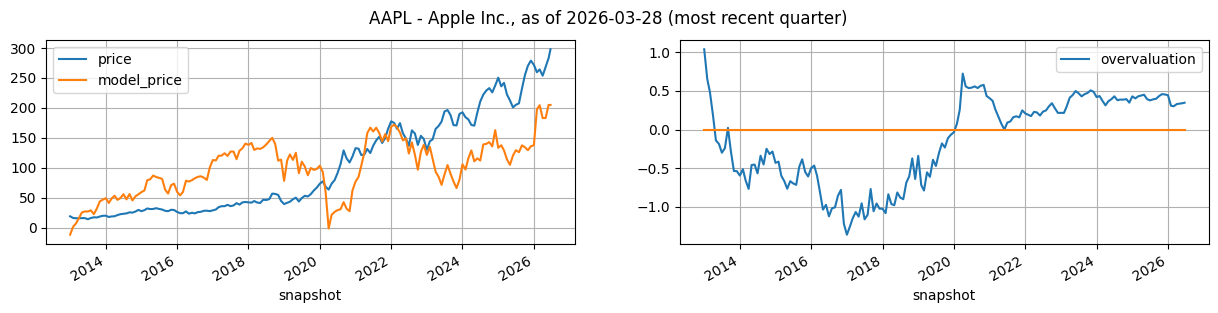

AAPL(0000320193) model_price = 0.833424 * (0.920230 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -39.698603


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-27,379.297,291.107,135.472,259.48,0.920231,1.674419,284.770616,0.833424,-39.698603,197.636133,0.307974
2026-03-01,2025-12-27,379.297,291.107,135.472,264.18,0.920231,1.735398,293.031468,0.833424,-39.698603,204.520927,0.301320
2026-04-01,2025-12-27,379.297,291.107,135.472,253.79,0.920231,1.544843,267.216701,0.833424,-39.698603,183.006275,0.329553
2026-05-01,2025-12-27,379.297,291.107,135.472,NaN,0.920231,1.544843,267.216701,0.833424,-39.698603,183.006275,NaN
2026-06-01,2026-03-28,371.082,264.591,140.222,NaN,0.920231,1.544843,293.511013,0.833424,-39.698603,204.920592,NaN
2026-06-20,2026-03-28,371.082,264.591,140.222,297.89,0.920231,1.544843,293.511013,0.833424,-39.698603,204.920592,0.347205


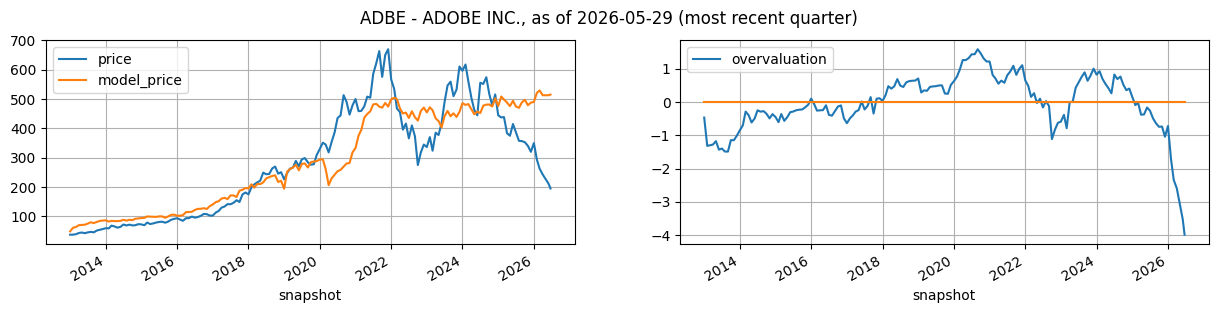

ADBE(0000796343) model_price = 13.161721 * (1.593147 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -82.950962


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-28,29.496,17.873,10.031,293.25,1.593147,1.674419,45.914573,13.161721,-82.950962,521.363858,-1.714428
2026-03-01,2025-11-28,29.496,17.873,10.031,262.41,1.593147,1.735398,46.526246,13.161721,-82.950962,529.414531,-2.345902
2026-04-01,2026-02-27,29.704,18.271,10.507,243.08,1.593147,1.544843,45.283517,13.161721,-82.950962,513.058069,-2.591365
2026-05-01,2026-02-27,29.704,18.271,10.507,NaN,1.593147,1.544843,45.283517,13.161721,-82.950962,513.058069,NaN
2026-06-01,2026-02-27,29.704,18.271,10.507,NaN,1.593147,1.544843,45.283517,13.161721,-82.950962,513.058069,NaN
2026-06-20,2026-05-29,29.933,18.415,10.481,195.15,1.593147,1.544843,45.464182,13.161721,-82.950962,515.435929,-3.989554


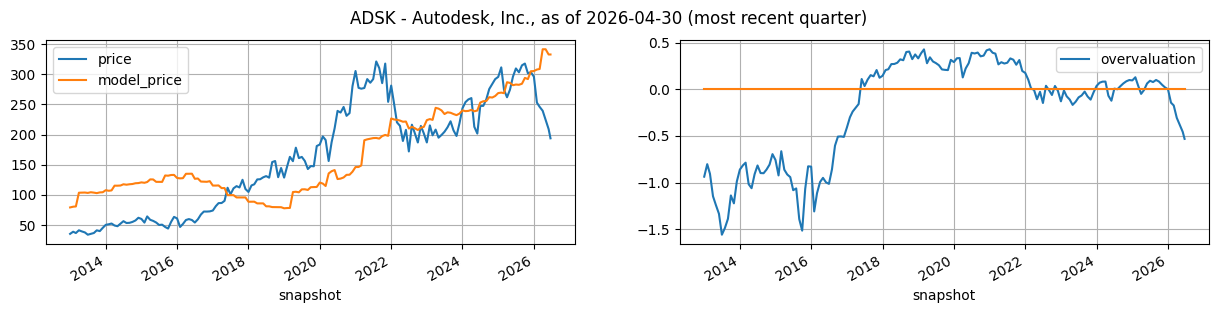

ADSK(0000769397) model_price = 6.947358 * (4.554727 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -13.968622


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-10-31,11.198,8.305,2.155,252.87,4.554728,1.674419,46.307213,6.947358,-13.968622,307.744155,-0.144058
2026-03-01,2025-10-31,11.198,8.305,2.155,245.87,4.554728,1.735398,46.438621,6.947358,-13.968622,308.657094,-0.173777
2026-04-01,2026-01-31,12.467,9.422,2.452,239.40,4.554728,1.544843,51.149745,6.947358,-13.968622,341.386954,-0.305977
2026-05-01,2026-01-31,12.467,9.422,2.452,NaN,4.554728,1.544843,51.149745,6.947358,-13.968622,341.386954,NaN
2026-06-01,2026-04-30,11.932,8.743,2.781,NaN,4.554728,1.544843,49.900219,6.947358,-13.968622,332.706051,NaN
2026-06-20,2026-04-30,11.932,8.743,2.781,193.76,4.554728,1.544843,49.900219,6.947358,-13.968622,332.706051,-0.531492


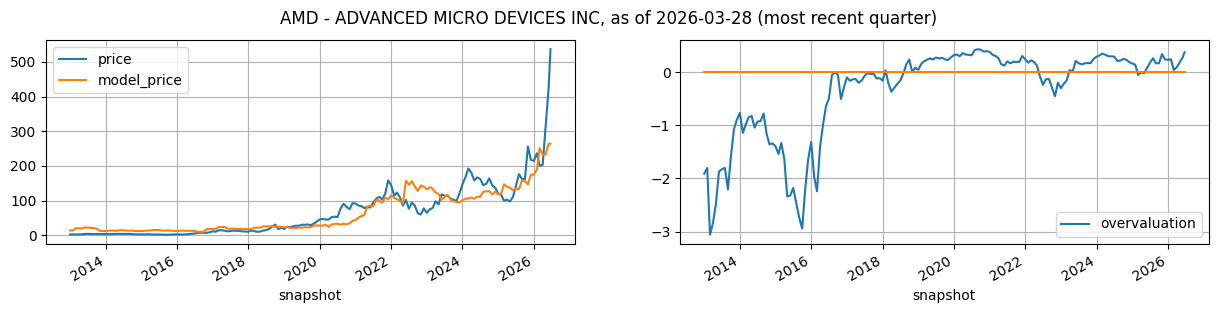

AMD(0000002488) model_price = 12.830255 * (0.211281 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +50.143961


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-27,76.891,16.101,6.408,236.73,0.211281,1.674419,10.874296,12.830255,50.143961,189.663954,0.237334
2026-03-01,2025-12-27,76.926,13.927,7.709,200.21,0.211281,1.735398,15.704192,12.830255,50.143961,251.632753,0.038989
2026-04-01,2025-12-27,76.926,13.927,7.709,203.43,0.211281,1.544843,14.235210,12.830255,50.143961,232.785329,0.087978
2026-05-01,2025-12-27,76.926,13.927,7.709,NaN,0.211281,1.544843,14.235210,12.830255,50.143961,232.785329,NaN
2026-06-01,2026-03-28,79.642,15.180,9.725,NaN,0.211281,1.544843,16.670453,12.830255,50.143961,264.030129,NaN
2026-06-20,2026-03-28,79.642,15.180,9.725,536.44,0.211281,1.544843,16.670453,12.830255,50.143961,264.030129,0.371835


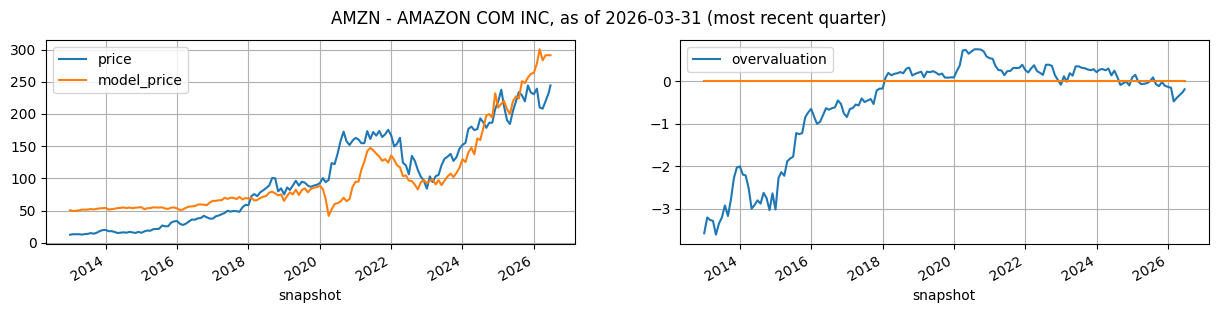

AMZN(0001018724) model_price = 0.622283 * (0.673374 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +54.851202


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,727.921,358.290,135.738750,239.30,0.673374,1.674419,359.156366,0.622283,54.851202,278.348177,-0.152998
2026-03-01,2025-12-31,818.042,406.977,144.561750,210.00,0.673374,1.735398,394.742998,0.622283,54.851202,300.493140,-0.473123
2026-04-01,2025-12-31,818.042,406.977,144.561750,208.27,0.673374,1.544843,367.196141,0.622283,54.851202,283.351193,-0.388925
2026-05-01,2026-03-31,916.630,474.716,153.635917,NaN,0.673374,1.544843,379.861862,0.622283,54.851202,291.232859,NaN
2026-06-01,2026-03-31,916.630,474.716,153.635917,NaN,0.673374,1.544843,379.861862,0.622283,54.851202,291.232859,NaN
2026-06-20,2026-03-31,916.630,474.716,153.635917,244.37,0.673374,1.544843,379.861862,0.622283,54.851202,291.232859,-0.187185


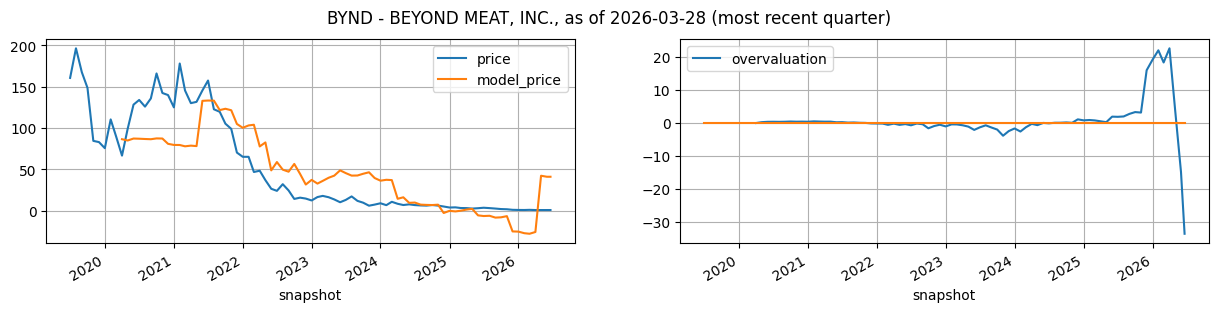

BYND(0001655210) model_price = 88.805159 * (1.746556 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +21.446075


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-27,0.599669,1.383734,-0.127090,0.7630,1.746557,1.674419,-0.549180,88.805159,21.446075,-27.323957,21.897615
2026-03-01,2025-09-27,0.599669,1.383734,-0.127090,0.9460,1.746557,1.735398,-0.556930,88.805159,21.446075,-28.012173,18.225652
2026-04-01,2025-09-27,0.599669,1.383734,-0.127090,0.7020,1.746557,1.544843,-0.532712,88.805159,21.446075,-25.861530,22.506785
2026-05-01,2025-12-31,0.614747,0.615744,-0.144931,NaN,1.746557,1.544843,0.234051,88.805159,21.446075,42.230982,NaN
2026-06-01,2026-03-28,0.579464,0.600547,-0.123813,NaN,1.746557,1.544843,0.220248,88.805159,21.446075,41.005227,NaN
2026-06-20,2026-03-28,0.579464,0.600547,-0.123813,0.7092,1.746557,1.544843,0.220248,88.805159,21.446075,41.005227,-33.554723


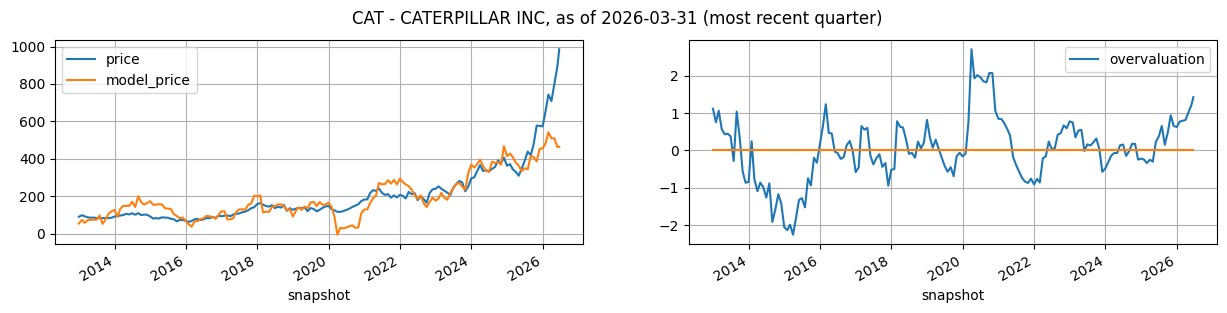

CAT(0000018230) model_price = 14.317336 * (1.478123 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -730.493406


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,93.722,73.063,11.541,657.36,1.478123,1.674419,84.794125,14.317336,-730.493406,483.532530,0.774867
2026-03-01,2025-12-31,98.585,77.267,11.739,742.83,1.478123,1.735398,88.825596,14.317336,-730.493406,541.252463,0.791885
2026-04-01,2025-12-31,98.585,77.267,11.739,708.46,1.478123,1.544843,86.588680,14.317336,-730.493406,509.225779,0.816085
2026-05-01,2025-12-31,98.585,77.267,11.739,NaN,1.478123,1.544843,86.588680,14.317336,-730.493406,509.225779,NaN
2026-06-01,2026-03-31,95.550,76.890,12.320,NaN,1.478123,1.544843,83.377130,14.317336,-730.493406,463.244948,NaN
2026-06-20,2026-03-31,95.550,76.890,12.320,985.43,1.478123,1.544843,83.377130,14.317336,-730.493406,463.244948,1.426623


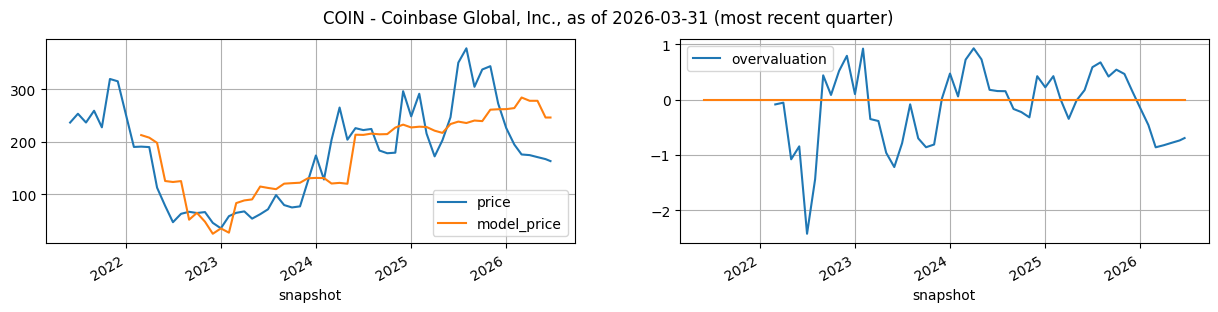

COIN(0001679788) model_price = 13.478138 * (1.015389 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +21.885591


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,31.351367,15.328143,0.872941,194.74,1.015389,1.674419,17.967347,13.478138,21.885591,264.051983,-0.460904
2026-03-01,2025-12-31,29.671832,14.878774,2.426383,175.85,1.015389,1.735398,19.460406,13.478138,21.885591,284.175631,-0.863016
2026-04-01,2025-12-31,29.671832,14.878774,2.426383,174.61,1.015389,1.544843,18.998048,13.478138,21.885591,277.943911,-0.825582
2026-05-01,2025-12-31,29.671832,14.878774,2.426383,NaN,1.015389,1.544843,18.998048,13.478138,21.885591,277.943911,NaN
2026-06-01,2026-03-31,28.848792,15.368219,1.756433,NaN,1.015389,1.544843,16.637930,13.478138,21.885591,246.133910,NaN
2026-06-20,2026-03-31,28.848792,15.368219,1.756433,163.23,1.015389,1.544843,16.637930,13.478138,21.885591,246.133910,-0.695865


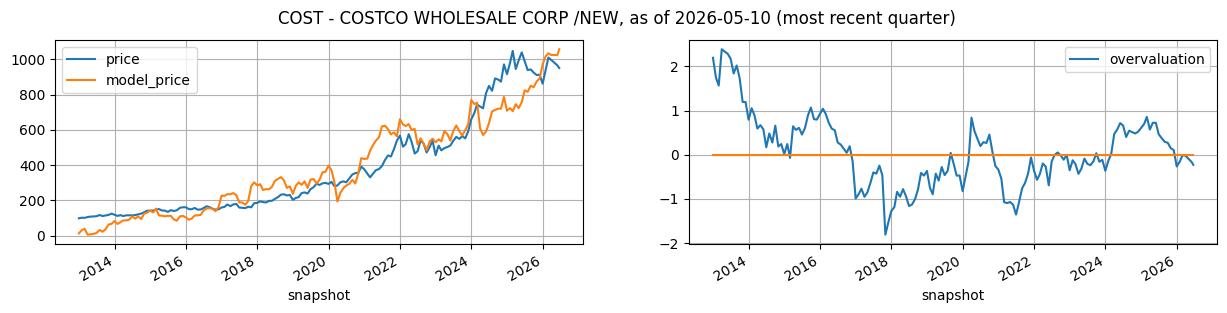

COST(0000909832) model_price = 18.539584 * (1.131132 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -203.106113


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-23,82.790,52.487,14.763,940.25,1.131132,1.674419,65.878892,18.539584,-203.106113,1018.261150,-0.155534
2026-03-01,2025-11-23,82.790,52.487,14.763,1010.79,1.131132,1.735398,66.779115,18.539584,-203.106113,1034.950901,-0.009340
2026-04-01,2026-02-15,83.639,51.552,15.011,996.43,1.131132,1.544843,66.244415,18.539584,-203.106113,1025.037784,-0.021239
2026-05-01,2026-02-15,83.639,51.552,15.011,NaN,1.131132,1.544843,66.244415,18.539584,-203.106113,1025.037784,NaN
2026-06-01,2026-02-15,83.639,51.552,15.011,NaN,1.131132,1.544843,66.244415,18.539584,-203.106113,1025.037784,NaN
2026-06-20,2026-05-10,86.430,52.921,15.000,951.27,1.131132,1.544843,68.015411,18.539584,-203.106113,1057.871328,-0.227543


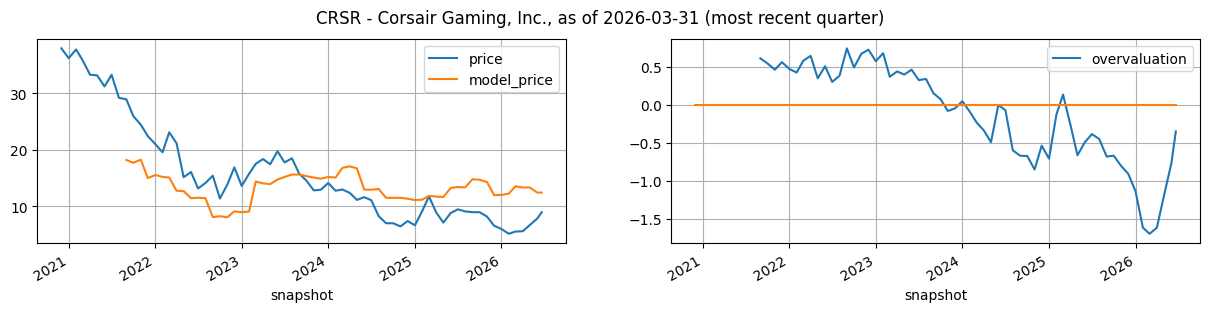

CRSR(0001743759) model_price = 21.229874 * (1.963414 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -27.431368


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,1.198499,0.598269,0.067507,5.10,1.963414,1.674419,1.867916,21.229874,-27.431368,12.224246,-1.614139
2026-03-01,2025-12-31,1.253784,0.620227,0.050121,5.49,1.963414,1.735398,1.928450,21.229874,-27.431368,13.509379,-1.694534
2026-04-01,2025-12-31,1.253784,0.620227,0.050121,5.55,1.963414,1.544843,1.918899,21.229874,-27.431368,13.306617,-1.614993
2026-05-01,2025-12-31,1.253784,0.620227,0.050121,NaN,1.963414,1.544843,1.918899,21.229874,-27.431368,13.306617,NaN
2026-06-01,2026-03-31,1.177340,0.529698,0.061099,NaN,1.963414,1.544843,1.876296,21.229874,-27.431368,12.402163,NaN
2026-06-20,2026-03-31,1.177340,0.529698,0.061099,8.91,1.963414,1.544843,1.876296,21.229874,-27.431368,12.402163,-0.348036


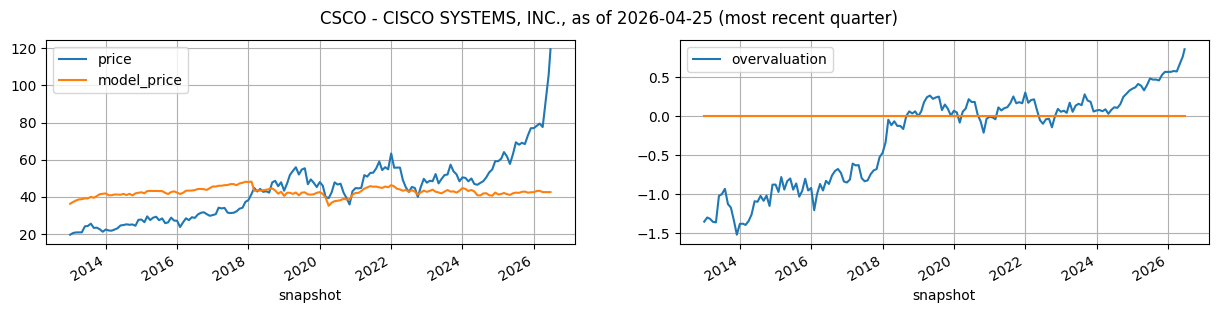

CSCO(0000858877) model_price = 0.281278 * (0.691896 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +34.043916


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-10-25,121.102,74.229,13.744,78.32,0.691896,1.674419,32.574234,0.281278,34.043916,43.206318,0.569521
2026-03-01,2026-01-24,123.371,75.648,13.325,79.46,0.691896,1.735398,32.836100,0.281278,34.043916,43.279975,0.579880
2026-04-01,2026-01-24,123.371,75.648,13.325,77.59,0.691896,1.544843,30.296965,0.281278,34.043916,42.565773,0.574065
2026-05-01,2026-01-24,123.371,75.648,13.325,NaN,0.691896,1.544843,30.296965,0.281278,34.043916,42.565773,NaN
2026-06-01,2026-04-25,125.546,76.685,13.025,NaN,0.691896,1.544843,30.301386,0.281278,34.043916,42.567017,NaN
2026-06-20,2026-04-25,125.546,76.685,13.025,119.44,0.691896,1.544843,30.301386,0.281278,34.043916,42.567017,0.859001


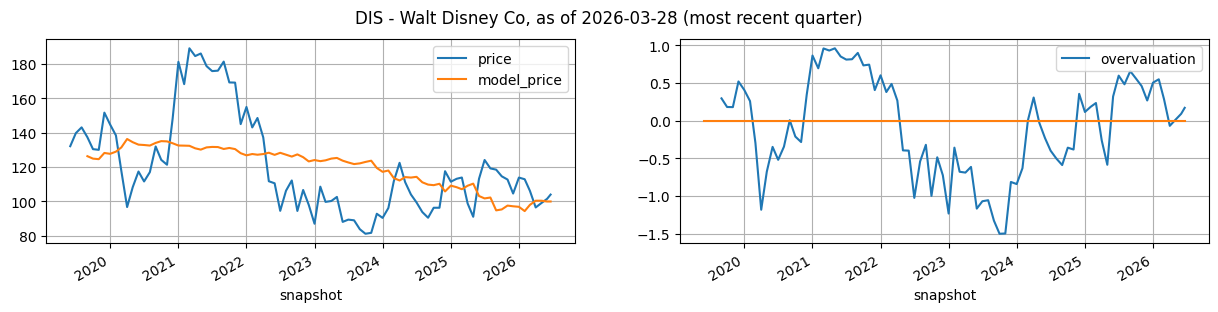

DIS(0001744489) model_price = -0.811767 * (1.024518 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +211.978846


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-27,197.514,87.645,18.101,112.80,1.024518,1.674419,145.020387,-0.811767,211.978846,94.256023,0.546281
2026-03-01,2025-12-27,202.089,93.613,15.631,106.04,1.024518,1.735398,140.556894,-0.811767,211.978846,97.879341,0.283340
2026-04-01,2025-12-27,202.089,93.613,15.631,96.38,1.024518,1.544843,137.578341,-0.811767,211.978846,100.297234,-0.070306
2026-05-01,2025-12-27,202.089,93.613,15.631,NaN,1.024518,1.544843,137.578341,-0.811767,211.978846,100.297234,NaN
2026-06-01,2026-03-28,205.217,96.509,15.792,NaN,1.024518,1.544843,138.135754,-0.811767,211.978846,99.844744,NaN
2026-06-20,2026-03-28,205.217,96.509,15.792,103.87,1.024518,1.544843,138.135754,-0.811767,211.978846,99.844744,0.168451


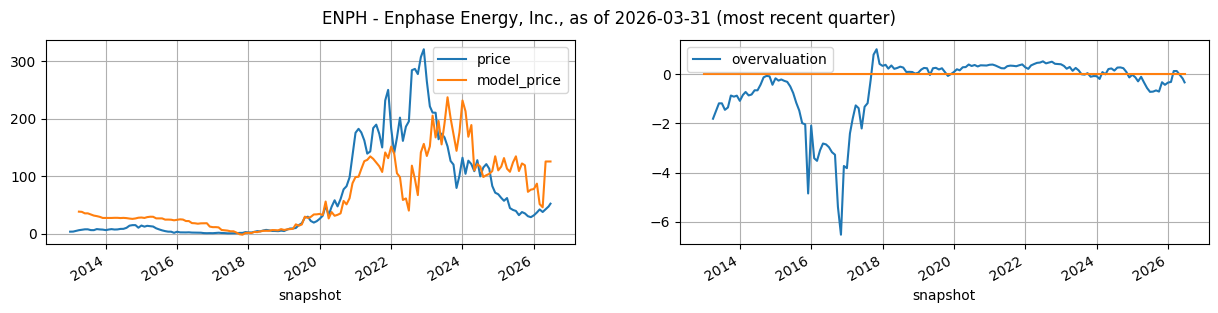

ENPH(0001463101) model_price = 214.518546 * (0.654446 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +27.728113


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,3.320488,2.325466,0.256253,36.98,0.654446,1.674419,0.276688,214.518546,27.728113,87.082888,-0.312179
2026-03-01,2025-12-31,3.509792,2.422769,0.136540,42.27,0.654446,1.735398,0.111151,214.518546,27.728113,51.572004,0.129154
2026-04-01,2025-12-31,3.509792,2.422769,0.136540,37.81,0.654446,1.544843,0.085132,214.518546,27.728113,45.990601,0.130593
2026-05-01,2026-03-31,2.723923,1.621571,0.190997,NaN,0.654446,1.544843,0.456149,214.518546,27.728113,125.580606,NaN
2026-06-01,2026-03-31,2.723923,1.621571,0.190997,NaN,0.654446,1.544843,0.456149,214.518546,27.728113,125.580606,NaN
2026-06-20,2026-03-31,2.723923,1.621571,0.190997,52.29,0.654446,1.544843,0.456149,214.518546,27.728113,125.580606,-0.330362


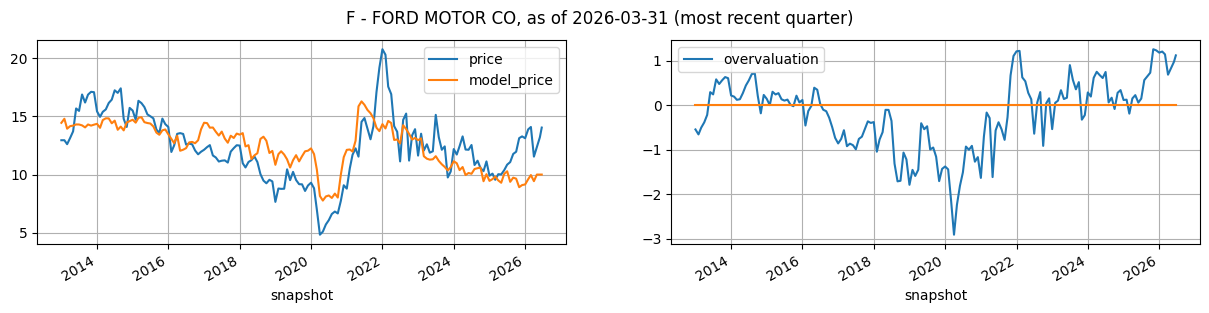

F(0000037996) model_price = 0.129565 * (0.029482 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +36.873712


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,300.990,253.598,20.426,13.880,0.029482,1.674419,-210.522661,0.129565,36.873712,9.597295,1.203292
2026-03-01,2025-12-31,289.160,253.208,21.282,14.090,0.029482,1.735398,-207.750385,0.129565,36.873712,9.956486,1.140593
2026-04-01,2025-12-31,289.160,253.208,21.282,11.540,0.029482,1.544843,-211.805761,0.129565,36.873712,9.431050,0.683935
2026-05-01,2026-03-31,282.434,244.981,18.919,NaN,0.029482,1.544843,-207.427518,0.129565,36.873712,9.998318,NaN
2026-06-01,2026-03-31,282.434,244.981,18.919,NaN,0.029482,1.544843,-207.427518,0.129565,36.873712,9.998318,NaN
2026-06-20,2026-03-31,282.434,244.981,18.919,14.038,0.029482,1.544843,-207.427518,0.129565,36.873712,9.998318,1.117485


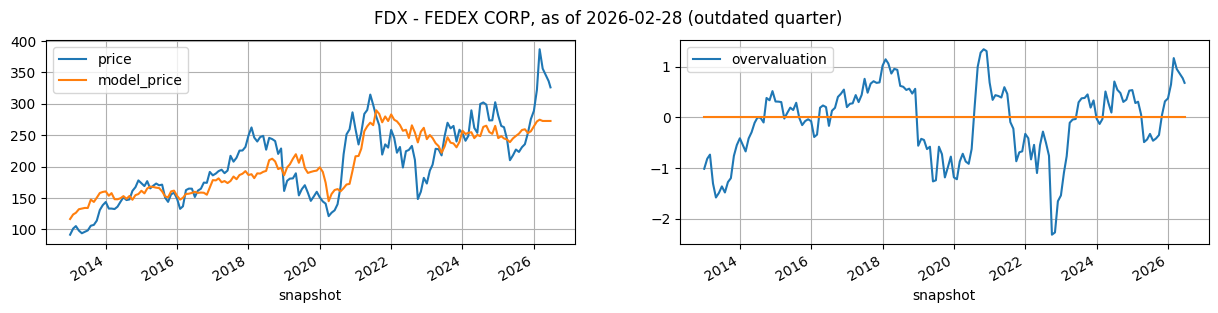

FDX(0001048911) model_price = 5.578814 * (0.921148 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +77.710460


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-30,89.181,61.041,8.198,322.25,0.921148,1.674419,34.834822,5.578814,77.71046,272.047437,0.650891
2026-03-01,2025-11-30,89.181,61.041,8.198,387.00,0.921148,1.735398,35.334722,5.578814,77.71046,274.836286,1.171842
2026-04-01,2026-02-28,94.733,64.929,8.179,356.18,0.921148,1.544843,34.969422,5.578814,77.71046,272.798345,0.955251
2026-05-01,2026-02-28,94.733,64.929,8.179,NaN,0.921148,1.544843,34.969422,5.578814,77.71046,272.798345,NaN
2026-06-01,2026-02-28,94.733,64.929,8.179,NaN,0.921148,1.544843,34.969422,5.578814,77.71046,272.798345,NaN
2026-06-20,2026-02-28,94.733,64.929,8.179,326.32,0.921148,1.544843,34.969422,5.578814,77.71046,272.798345,0.682870


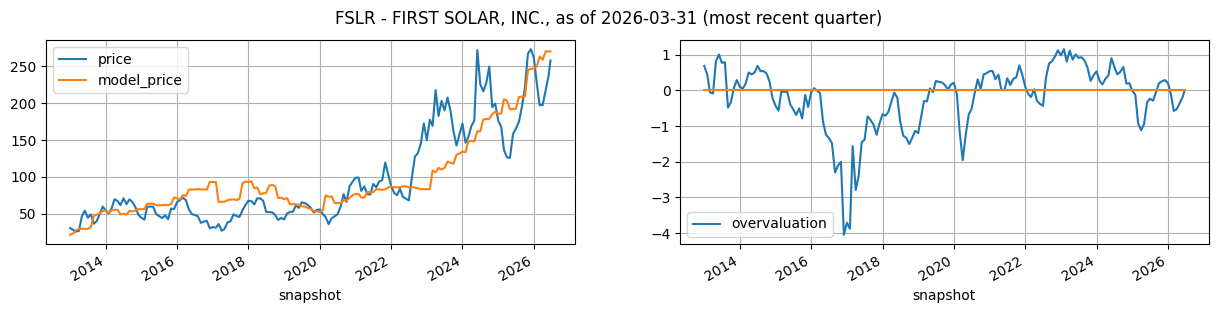

FSLR(0001274494) model_price = 11.402929 * (2.485589 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -111.968501


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,13.459309,4.443997,1.626208,225.52,2.485589,1.674419,31.733265,11.402929,-111.968501,249.883666,-0.119647
2026-03-01,2025-12-31,13.321310,3.783317,2.057105,197.20,2.485589,1.735398,32.897877,11.402929,-111.968501,263.163657,-0.572576
2026-04-01,2025-12-31,13.321310,3.783317,2.057105,197.26,2.485589,1.544843,32.505887,11.402929,-111.968501,258.693822,-0.526446
2026-05-01,2026-03-31,13.351097,3.472529,2.450221,NaN,2.485589,1.544843,33.498016,11.402929,-111.968501,270.006997,NaN
2026-06-01,2026-03-31,13.351097,3.472529,2.450221,NaN,2.485589,1.544843,33.498016,11.402929,-111.968501,270.006997,NaN
2026-06-20,2026-03-31,13.351097,3.472529,2.450221,257.65,2.485589,1.544843,33.498016,11.402929,-111.968501,270.006997,0.000497


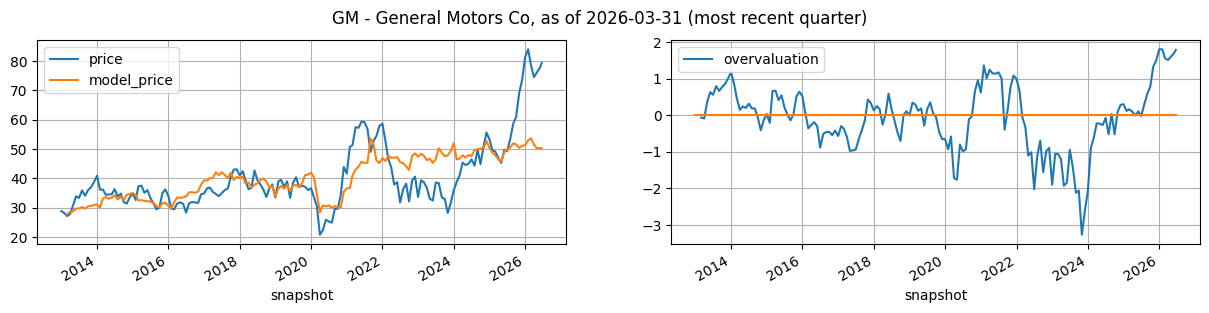

GM(0001467858) model_price = 0.407210 * (0.860704 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +25.735101


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-31,281.284,220.165,26.867,84.000,0.860704,1.674419,66.923841,0.40721,25.735101,52.987175,1.811054
2026-03-01,2025-12-31,281.284,220.165,26.867,78.710,0.860704,1.735398,68.562145,0.40721,25.735101,53.654309,1.568257
2026-04-01,2025-12-31,281.284,220.165,26.867,74.500,0.860704,1.544843,63.442524,0.40721,25.735101,51.569547,1.517962
2026-05-01,2026-03-31,280.974,218.315,23.756,NaN,0.860704,1.544843,60.219697,0.40721,25.735101,50.257179,NaN
2026-06-01,2026-03-31,280.974,218.315,23.756,NaN,0.860704,1.544843,60.219697,0.40721,25.735101,50.257179,NaN
2026-06-20,2026-03-31,280.974,218.315,23.756,79.305,0.860704,1.544843,60.219697,0.40721,25.735101,50.257179,1.797115


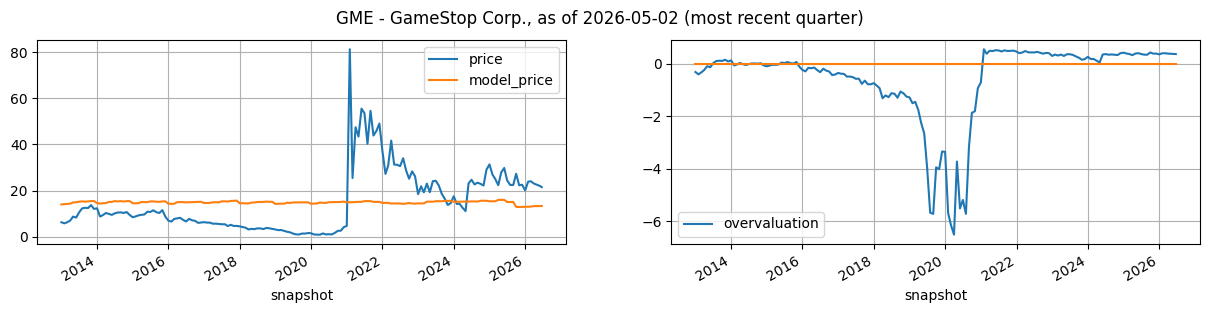

GME(0001326380) model_price = 0.831582 * (0.000473 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +16.589631


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-01,10.5507,5.2477,0.5835,23.880,0.000473,1.674419,-4.265690,0.831582,16.589631,13.042361,0.391136
2026-03-01,2025-11-01,10.5507,5.2477,0.5835,24.030,0.000473,1.735398,-4.230109,0.831582,16.589631,13.071950,0.392059
2026-04-01,2026-01-31,10.3884,4.9440,0.6148,23.040,0.000473,1.544843,-3.989320,0.831582,16.589631,13.272185,0.378468
2026-05-01,2026-01-31,10.3884,4.9440,0.6148,NaN,0.000473,1.544843,-3.989320,0.831582,16.589631,13.272185,NaN
2026-06-01,2026-01-31,10.3884,4.9440,0.6148,NaN,0.000473,1.544843,-3.989320,0.831582,16.589631,13.272185,NaN
2026-06-20,2026-05-02,10.9743,5.1322,0.7597,21.495,0.000473,1.544843,-3.953395,0.831582,16.589631,13.302059,0.360329


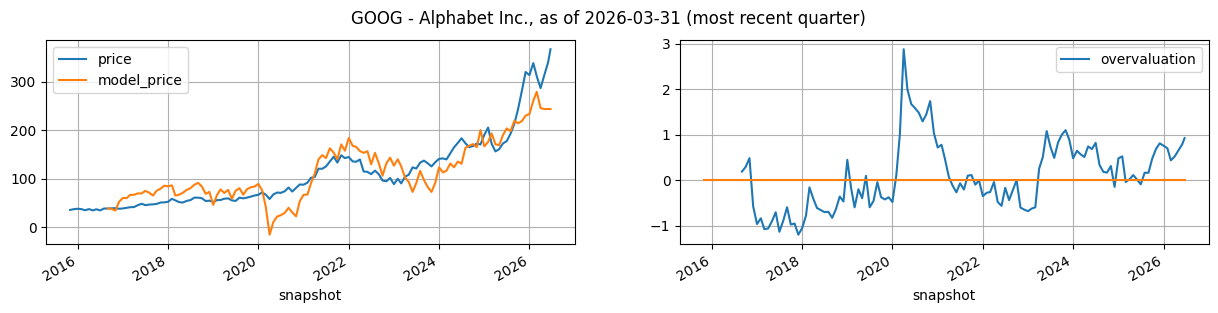

GOOG(0001652044) model_price = 1.068134 * (0.261628 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -0.174315


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,536.469,149.602,151.424,338.53,0.261628,1.674419,244.300468,1.068134,-0.174315,260.771411,0.707040
2026-03-01,2025-12-31,595.281,180.016,164.713,311.43,0.261628,1.735398,261.568597,1.068134,-0.174315,279.216093,0.442402
2026-04-01,2025-12-31,595.281,180.016,164.713,286.86,0.261628,1.544843,230.181833,1.068134,-0.174315,245.690812,0.526407
2026-05-01,2026-03-31,703.919,225.173,174.353,NaN,0.261628,1.544843,228.339841,1.068134,-0.174315,243.723316,NaN
2026-06-01,2026-03-31,703.919,225.173,174.353,NaN,0.261628,1.544843,228.339841,1.068134,-0.174315,243.723316,NaN
2026-06-20,2026-03-31,703.919,225.173,174.353,367.11,0.261628,1.544843,228.339841,1.068134,-0.174315,243.723316,0.930076


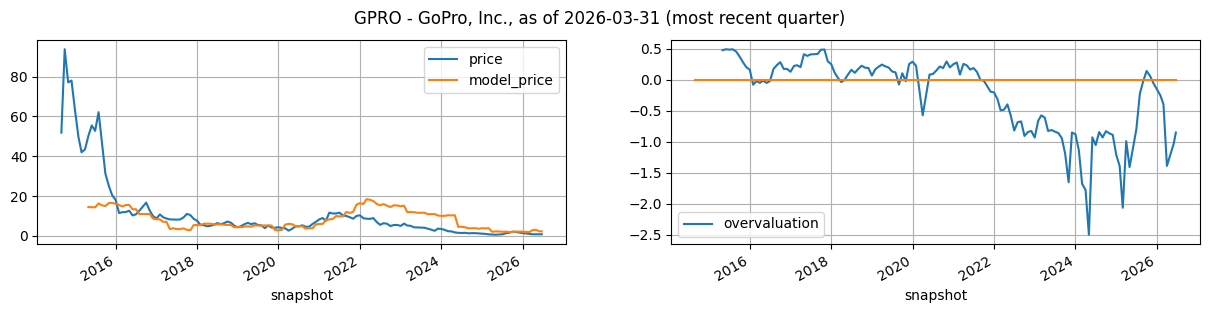

GPRO(0001500435) model_price = 15.456645 * (1.007635 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +2.231198


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,0.538608,0.458114,-0.061371,1.1600,1.007635,1.674419,-0.018155,15.456645,2.231198,1.950588,-0.249260
2026-03-01,2025-09-30,0.538608,0.458114,-0.061371,0.9680,1.007635,1.735398,-0.021897,15.456645,2.231198,1.892744,-0.392376
2026-04-01,2025-12-31,0.427983,0.351433,-0.020669,0.7700,1.007635,1.544843,0.047887,15.456645,2.231198,2.971373,-1.387493
2026-05-01,2025-12-31,0.427983,0.351433,-0.020669,NaN,1.007635,1.544843,0.047887,15.456645,2.231198,2.971373,NaN
2026-06-01,2026-03-31,0.381355,0.383224,-0.000101,NaN,1.007635,1.544843,0.000887,15.456645,2.231198,2.244900,NaN
2026-06-20,2026-03-31,0.381355,0.383224,-0.000101,0.7931,1.007635,1.544843,0.000887,15.456645,2.231198,2.244900,-0.849901


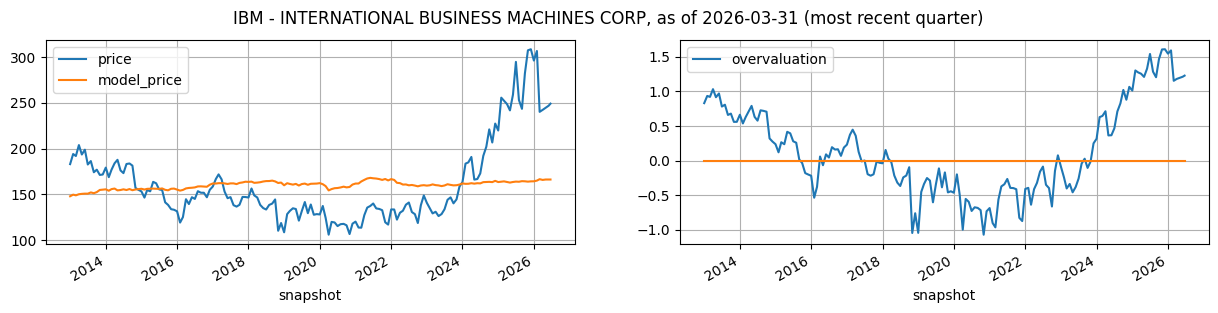

IBM(0000051143) model_price = 0.322809 * (0.959040 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +150.758710


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,146.312,118.407,13.483,306.70,0.95904,1.674419,44.488255,0.322809,150.75871,165.119900,1.593030
2026-03-01,2025-12-31,151.880,119.232,13.193,240.21,0.95904,1.735398,49.322095,0.322809,150.75871,166.680305,1.153576
2026-04-01,2025-12-31,151.880,119.232,13.193,242.39,0.95904,1.544843,46.808113,0.322809,150.75871,165.868770,1.180671
2026-05-01,2026-03-31,156.229,123.255,13.992,NaN,0.95904,1.544843,48.190307,0.322809,150.75871,166.314954,NaN
2026-06-01,2026-03-31,156.229,123.255,13.992,NaN,0.95904,1.544843,48.190307,0.322809,150.75871,166.314954,NaN
2026-06-20,2026-03-31,156.229,123.255,13.992,249.18,0.95904,1.544843,48.190307,0.322809,150.75871,166.314954,1.228303


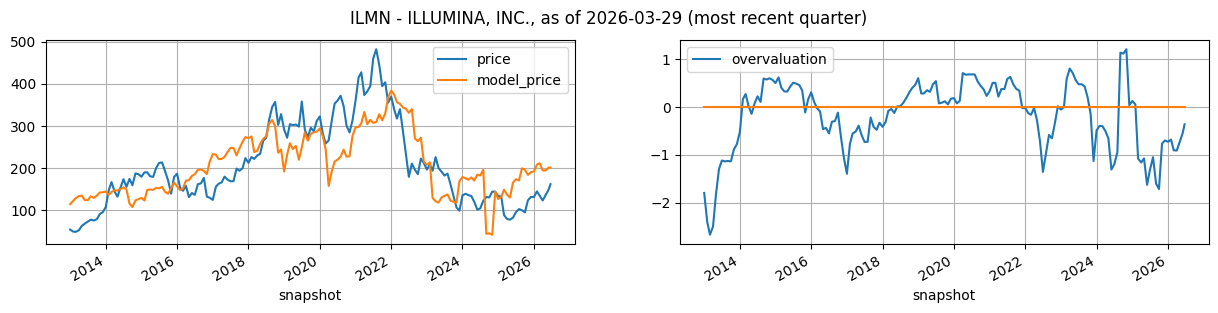

ILMN(0001110803) model_price = 84.018845 * (0.367245 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +178.750253


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-28,6.177,3.796,1.122,144.81,0.367245,1.674419,0.351170,84.018845,178.750253,208.255161,-0.680194
2026-03-01,2025-12-28,6.644,3.921,1.079,134.46,0.367245,1.735398,0.391469,84.018845,178.750253,211.641028,-0.904194
2026-04-01,2025-12-28,6.644,3.921,1.079,123.26,0.367245,1.544843,0.185861,84.018845,178.750253,194.366078,-0.908928
2026-05-01,2025-12-28,6.644,3.921,1.079,NaN,0.367245,1.544843,0.185861,84.018845,178.750253,194.366078,NaN
2026-06-01,2026-03-29,6.559,3.883,1.128,NaN,0.367245,1.544843,0.268342,84.018845,178.750253,201.296079,NaN
2026-06-20,2026-03-29,6.559,3.883,1.128,161.91,0.367245,1.544843,0.268342,84.018845,178.750253,201.296079,-0.358952


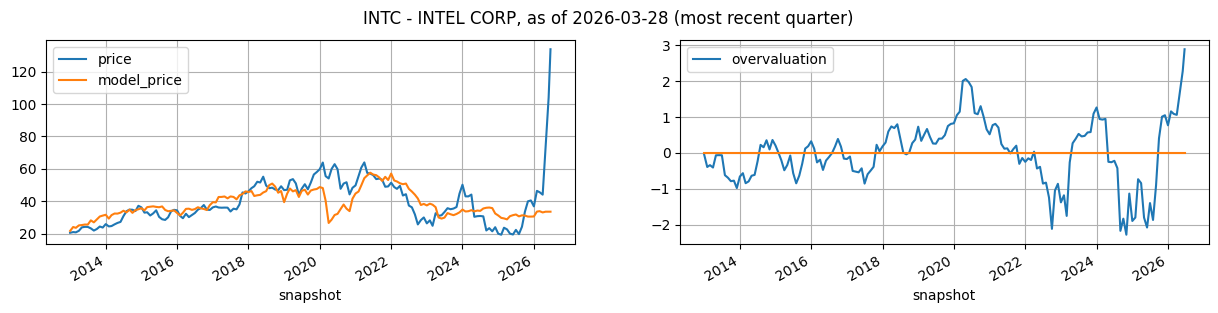

INTC(0000050863) model_price = 0.419284 * (0.417225 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +30.624452


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-27,211.429,97.148,9.697,46.47,0.417225,1.674419,7.302398,0.419284,30.624452,33.686233,1.159768
2026-03-01,2025-12-27,211.429,97.148,9.697,45.61,0.417225,1.735398,7.893705,0.419284,30.624452,33.934158,1.089841
2026-04-01,2025-12-27,211.429,97.148,9.697,44.13,0.417225,1.544843,6.045900,0.419284,30.624452,33.159403,1.062770
2026-05-01,2026-03-28,205.332,93.938,9.980,NaN,0.417225,1.544843,7.149268,0.419284,30.624452,33.622027,NaN
2026-06-01,2026-03-28,205.332,93.938,9.980,NaN,0.417225,1.544843,7.149268,0.419284,30.624452,33.622027,NaN
2026-06-20,2026-03-28,205.332,93.938,9.980,133.79,0.417225,1.544843,7.149268,0.419284,30.624452,33.622027,2.893274


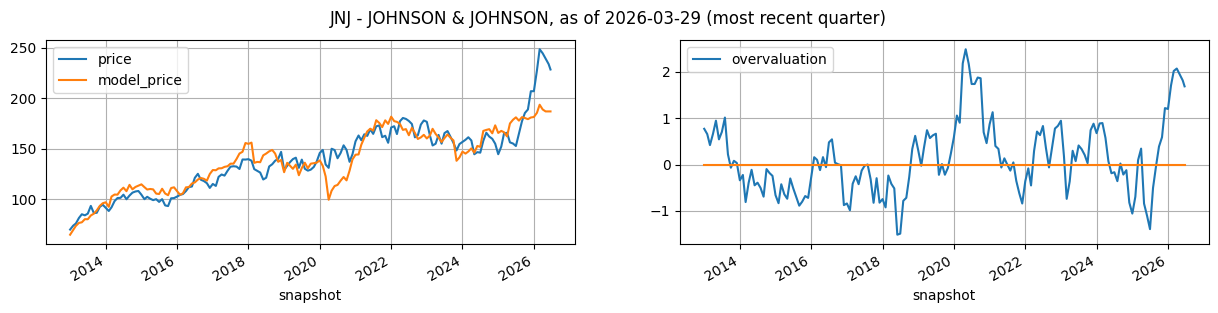

JNJ(0000200406) model_price = 0.998652 * (1.584227 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -46.620856


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-28,192.816,113.539,24.204,227.25,1.584227,1.674419,232.452885,0.998652,-46.620856,185.518778,1.702523
2026-03-01,2025-12-28,199.210,117.666,24.530,248.43,1.584227,1.735398,240.497088,0.998652,-46.620856,193.552141,2.015046
2026-04-01,2025-12-28,199.210,117.666,24.530,244.44,1.584227,1.544843,235.822792,0.998652,-46.620856,188.884144,2.068550
2026-05-01,2026-03-29,200.894,119.708,22.870,NaN,1.584227,1.544843,233.884190,0.998652,-46.620856,186.948154,NaN
2026-06-01,2026-03-29,200.894,119.708,22.870,NaN,1.584227,1.544843,233.884190,0.998652,-46.620856,186.948154,NaN
2026-06-20,2026-03-29,200.894,119.708,22.870,228.40,1.584227,1.544843,233.884190,0.998652,-46.620856,186.948154,1.684510


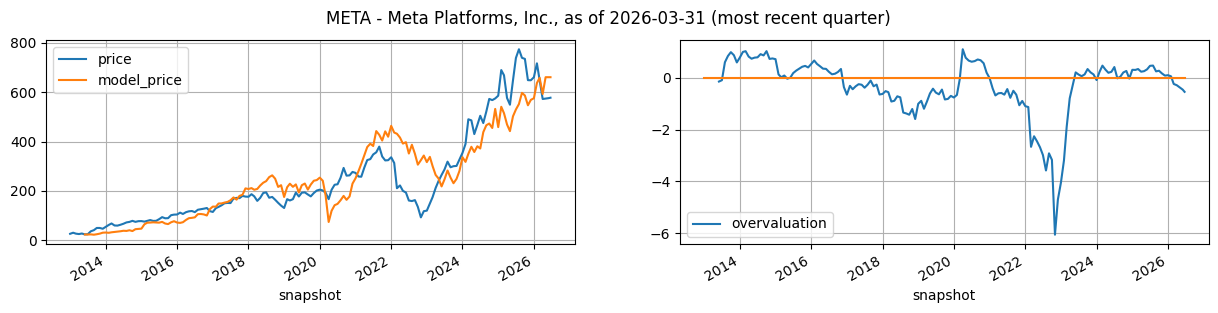

META(0001326801) model_price = 2.969582 * (0.446405 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +17.591902


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-31,366.021,148.778,115.8,716.50,0.446405,1.674419,208.513249,2.969582,17.591902,636.789123,0.064178
2026-03-01,2025-12-31,366.021,148.778,115.8,648.18,0.446405,1.735398,215.574535,2.969582,17.591902,657.758192,-0.233569
2026-04-01,2025-12-31,366.021,148.778,115.8,572.13,0.446405,1.544843,193.508352,2.969582,17.591902,592.230848,-0.281661
2026-05-01,2026-03-31,395.250,151.569,124.0,NaN,0.446405,1.544843,216.433030,2.969582,17.591902,660.307563,NaN
2026-06-01,2026-03-31,395.250,151.569,124.0,NaN,0.446405,1.544843,216.433030,2.969582,17.591902,660.307563,NaN
2026-06-20,2026-03-31,395.250,151.569,124.0,577.30,0.446405,1.544843,216.433030,2.969582,17.591902,660.307563,-0.538359


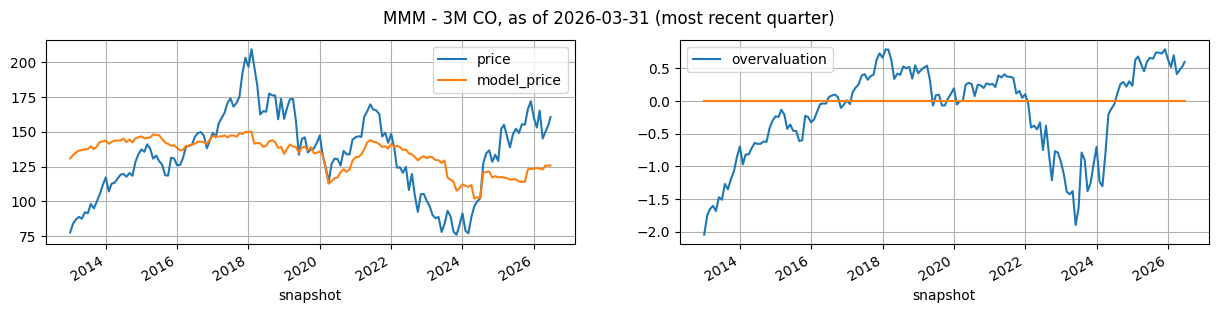

MMM(0000066740) model_price = 1.523442 * (0.001015 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +167.780585


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,37.611,32.983,2.541,153.16,0.001015,1.674419,-28.690124,1.523442,167.780585,124.072855,0.518769
2026-03-01,2025-12-31,37.733,33.031,2.306,165.32,0.001015,1.735398,-28.990873,1.523442,167.780585,123.614681,0.700821
2026-04-01,2025-12-31,37.733,33.031,2.306,145.23,0.001015,1.544843,-29.430291,1.523442,167.780585,122.945254,0.412297
2026-05-01,2026-03-31,35.436,32.173,2.959,NaN,0.001015,1.544843,-27.565840,1.523442,167.780585,125.785636,NaN
2026-06-01,2026-03-31,35.436,32.173,2.959,NaN,0.001015,1.544843,-27.565840,1.523442,167.780585,125.785636,NaN
2026-06-20,2026-03-31,35.436,32.173,2.959,160.63,0.001015,1.544843,-27.565840,1.523442,167.780585,125.785636,0.597624


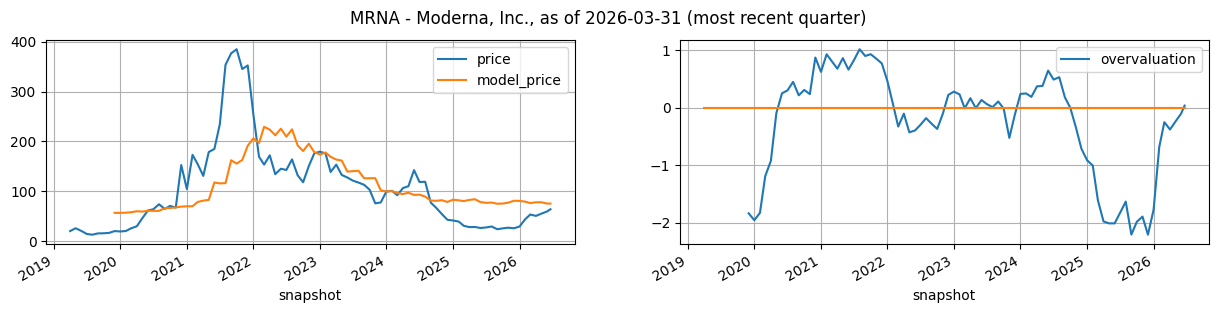

MRNA(0001682852) model_price = 4.607026 * (0.945472 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +54.686878


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,12.135,2.805,-1.978,44.07,0.945472,1.674419,5.356303,4.607026,54.686878,79.363505,-0.685995
2026-03-01,2025-12-31,12.338,3.688,-1.873,53.57,0.945472,1.735398,4.726836,4.607026,54.686878,76.463532,-0.254505
2026-04-01,2025-12-31,12.338,3.688,-1.873,50.80,0.945472,1.544843,5.083744,4.607026,54.686878,78.107817,-0.381815
2026-05-01,2025-12-31,12.338,3.688,-1.873,NaN,0.945472,1.544843,5.083744,4.607026,54.686878,78.107817,NaN
2026-06-01,2026-03-31,11.488,4.080,-1.466,NaN,0.945472,1.544843,4.516844,4.607026,54.686878,75.496094,NaN
2026-06-20,2026-03-31,11.488,4.080,-1.466,64.10,0.945472,1.544843,4.516844,4.607026,54.686878,75.496094,0.033819


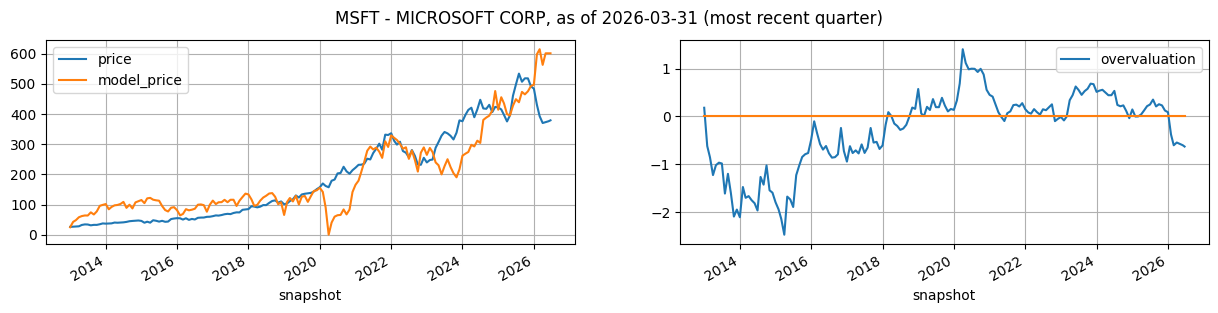

MSFT(0000789019) model_price = 1.689486 * (0.455219 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +95.479473


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-31,665.302,274.427,160.506,430.29,0.455219,1.674419,297.185631,1.689486,95.479473,597.570523,-0.376823
2026-03-01,2025-12-31,665.302,274.427,160.506,392.74,0.455219,1.735398,306.973013,1.689486,95.479473,614.106170,-0.601798
2026-04-01,2025-12-31,665.302,274.427,160.506,370.17,0.455219,1.544843,276.387911,1.689486,95.479473,562.433059,-0.544868
2026-05-01,2026-03-31,694.228,279.861,170.141,NaN,0.455219,1.544843,299.006149,1.689486,95.479473,600.646263,NaN
2026-06-01,2026-03-31,694.228,279.861,170.141,NaN,0.455219,1.544843,299.006149,1.689486,95.479473,600.646263,NaN
2026-06-20,2026-03-31,694.228,279.861,170.141,379.05,0.455219,1.544843,299.006149,1.689486,95.479473,600.646263,-0.628766


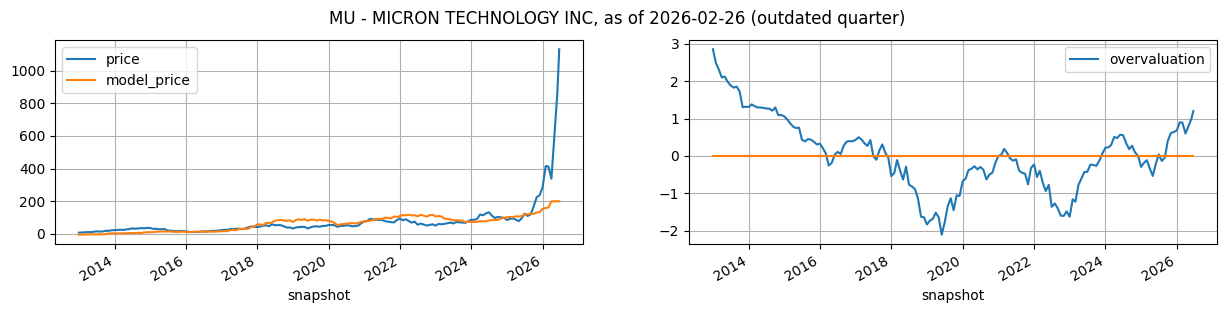

MU(0000723125) model_price = 1.527943 * (1.217483 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -18.143746


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-27,85.971,27.165,22.692,414.88,1.217483,1.674419,115.499170,1.527943,-18.143746,158.332354,0.897923
2026-03-01,2025-11-27,85.971,27.165,22.692,412.37,1.217483,1.735398,116.882890,1.527943,-18.143746,160.446598,0.887074
2026-04-01,2026-02-26,101.509,29.050,30.653,337.84,1.217483,1.544843,141.889584,1.527943,-18.143746,198.655391,0.597384
2026-05-01,2026-02-26,101.509,29.050,30.653,NaN,1.217483,1.544843,141.889584,1.527943,-18.143746,198.655391,NaN
2026-06-01,2026-02-26,101.509,29.050,30.653,NaN,1.217483,1.544843,141.889584,1.527943,-18.143746,198.655391,NaN
2026-06-20,2026-02-26,101.509,29.050,30.653,1132.01,1.217483,1.544843,141.889584,1.527943,-18.143746,198.655391,1.198118


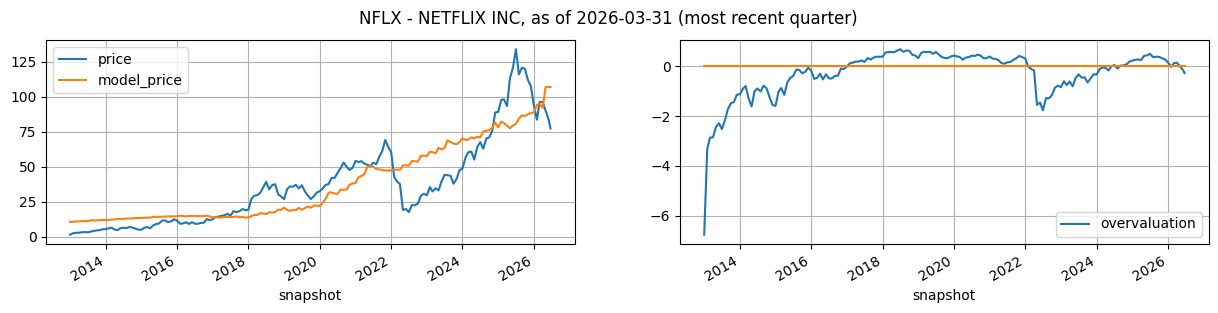

NFLX(0001065280) model_price = 1.594021 * (1.181148 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +8.482224


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-31,55.596993,28.981505,10.149273,83.49,1.181148,1.674419,53.680928,1.594021,8.482224,94.050733,-0.014886
2026-03-01,2025-12-31,55.596993,28.981505,10.149273,96.24,1.181148,1.735398,54.299813,1.594021,8.482224,95.037249,0.122526
2026-04-01,2025-12-31,55.596993,28.981505,10.149273,96.15,1.181148,1.544843,52.365826,1.594021,8.482224,91.954433,0.153311
2026-05-01,2026-03-31,61.015914,29.889515,12.650279,NaN,1.181148,1.544843,61.722028,1.594021,8.482224,106.868413,NaN
2026-06-01,2026-03-31,61.015914,29.889515,12.650279,NaN,1.181148,1.544843,61.722028,1.594021,8.482224,106.868413,NaN
2026-06-20,2026-03-31,61.015914,29.889515,12.650279,77.33,1.181148,1.544843,61.722028,1.594021,8.482224,106.868413,-0.267477


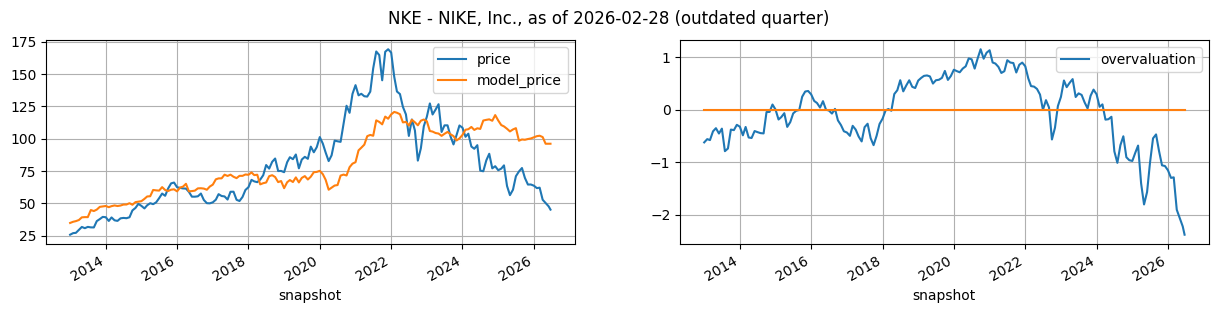

NKE(0000320187) model_price = 1.773262 * (2.120149 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -7.089521


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-30,37.787,23.702,3.056,61.810,2.120149,1.674419,61.529110,1.773262,-7.089521,102.017739,-1.296410
2026-03-01,2025-11-30,37.787,23.702,3.056,62.180,2.120149,1.735398,61.715460,1.773262,-7.089521,102.348186,-1.286201
2026-04-01,2025-11-30,37.787,23.702,3.056,52.820,2.120149,1.544843,61.133126,1.773262,-7.089521,101.315556,-1.902643
2026-05-01,2026-02-28,37.064,22.974,1.694,NaN,2.120149,1.544843,58.224181,1.773262,-7.089521,96.157233,NaN
2026-06-01,2026-02-28,37.064,22.974,1.694,NaN,2.120149,1.544843,58.224181,1.773262,-7.089521,96.157233,NaN
2026-06-20,2026-02-28,37.064,22.974,1.694,45.195,2.120149,1.544843,58.224181,1.773262,-7.089521,96.157233,-2.377165


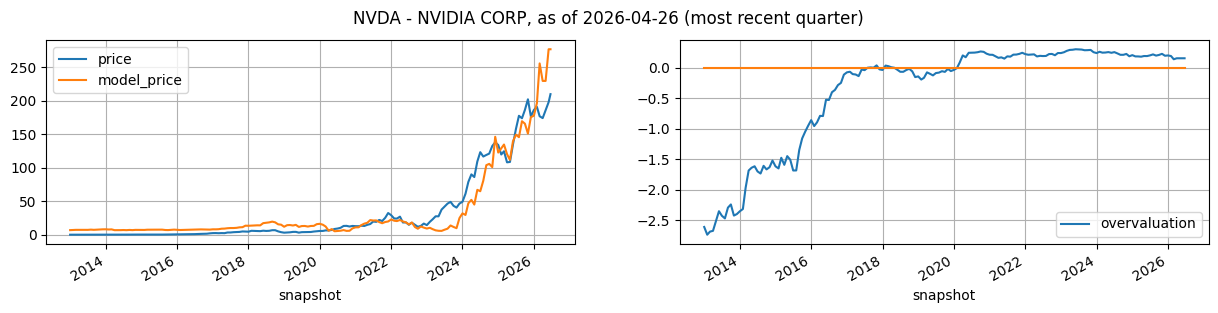

NVDA(0001045810) model_price = 1.335012 * (0.275390 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +8.148785


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-10-26,161.148,42.251,83.159,191.13,0.27539,1.674419,141.370615,1.335012,8.148785,196.880185,0.191000
2026-03-01,2026-01-25,206.803,49.510,102.718,177.19,0.27539,1.735398,185.698089,1.335012,8.148785,256.057875,0.138129
2026-04-01,2026-01-25,206.803,49.510,102.718,174.40,0.27539,1.544843,166.124737,1.335012,8.148785,229.927223,0.154272
2026-05-01,2026-01-25,206.803,49.510,102.718,NaN,0.27539,1.544843,166.124737,1.335012,8.148785,229.927223,NaN
2026-06-01,2026-04-26,259.474,64.000,125.648,NaN,0.27539,1.544843,201.563071,1.335012,8.148785,277.237808,NaN
2026-06-20,2026-04-26,259.474,64.000,125.648,210.20,0.27539,1.544843,201.563071,1.335012,8.148785,277.237808,0.154204


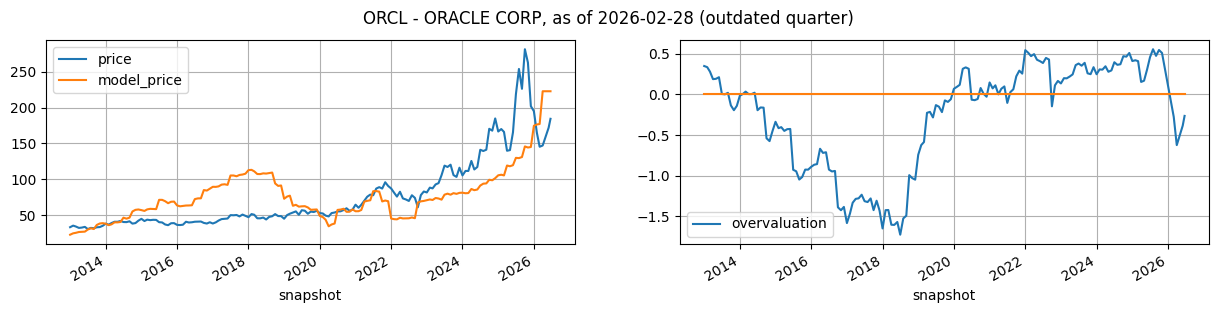

ORCL(0001341439) model_price = 0.484252 * (3.186850 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -73.216576


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-30,204.984,175.033,22.296,164.58,3.18685,1.674419,515.553032,0.484252,-73.216576,176.441003,-0.105111
2026-03-01,2025-11-30,204.984,175.033,22.296,145.40,3.18685,1.735398,516.912604,0.484252,-73.216576,177.099379,-0.276681
2026-04-01,2026-02-28,245.240,206.745,23.514,147.11,3.18685,1.544843,611.123443,0.484252,-73.216576,222.721165,-0.624606
2026-05-01,2026-02-28,245.240,206.745,23.514,NaN,3.18685,1.544843,611.123443,0.484252,-73.216576,222.721165,NaN
2026-06-01,2026-02-28,245.240,206.745,23.514,NaN,3.18685,1.544843,611.123443,0.484252,-73.216576,222.721165,NaN
2026-06-20,2026-02-28,245.240,206.745,23.514,184.33,3.18685,1.544843,611.123443,0.484252,-73.216576,222.721165,-0.265230


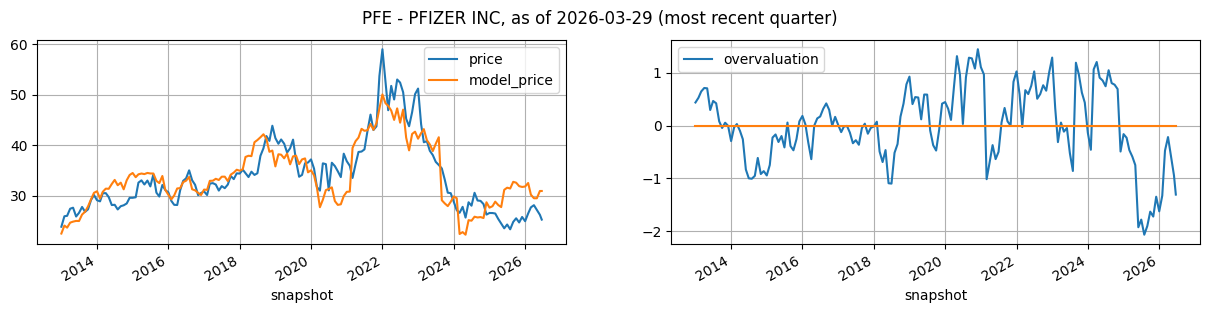

PFE(0000078003) model_price = 0.315667 * (0.048574 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +58.968985


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-28,208.731,115.930,13.077,26.44,0.048574,1.674419,-83.894637,0.315667,58.968985,32.486245,-1.328038
2026-03-01,2025-12-31,208.160,121.684,11.704,27.65,0.048574,1.735398,-91.261661,0.315667,58.968985,30.160721,-0.475573
2026-04-01,2025-12-31,208.160,121.684,11.704,28.08,0.048574,1.544843,-93.491908,0.315667,58.968985,29.456706,-0.217278
2026-05-01,2025-12-31,208.160,121.684,11.704,NaN,0.048574,1.544843,-93.491908,0.315667,58.968985,29.456706,NaN
2026-06-01,2026-03-29,207.618,117.517,11.984,NaN,0.048574,1.544843,-88.918679,0.315667,58.968985,30.900322,NaN
2026-06-20,2026-03-29,207.618,117.517,11.984,25.22,0.048574,1.544843,-88.918679,0.315667,58.968985,30.900322,-1.306725


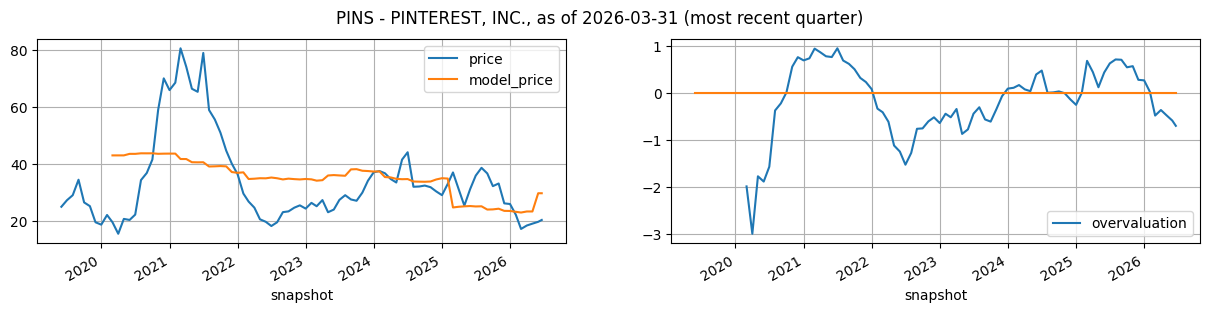

PINS(0001506293) model_price = -1.531924 * (3.630786 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +55.713391


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,5.515410,0.690442,1.147046,22.13,3.630785,1.674419,21.255462,-1.531924,55.713391,23.151648,0.018488
2026-03-01,2025-12-31,5.492132,0.746894,1.284264,17.13,3.630785,1.735398,21.422565,-1.531924,55.713391,22.895659,-0.485712
2026-04-01,2025-12-31,5.492132,0.746894,1.284264,18.34,3.630785,1.544843,21.177843,-1.531924,55.713391,23.270554,-0.368105
2026-05-01,2025-12-31,5.492132,0.746894,1.284264,NaN,3.630785,1.544843,21.177843,-1.531924,55.713391,23.270554,NaN
2026-06-01,2026-03-31,4.645279,1.794695,1.248581,NaN,3.630785,1.544843,17.000176,-1.531924,55.713391,29.670420,NaN
2026-06-20,2026-03-31,4.645279,1.794695,1.248581,20.29,3.630785,1.544843,17.000176,-1.531924,55.713391,29.670420,-0.704003


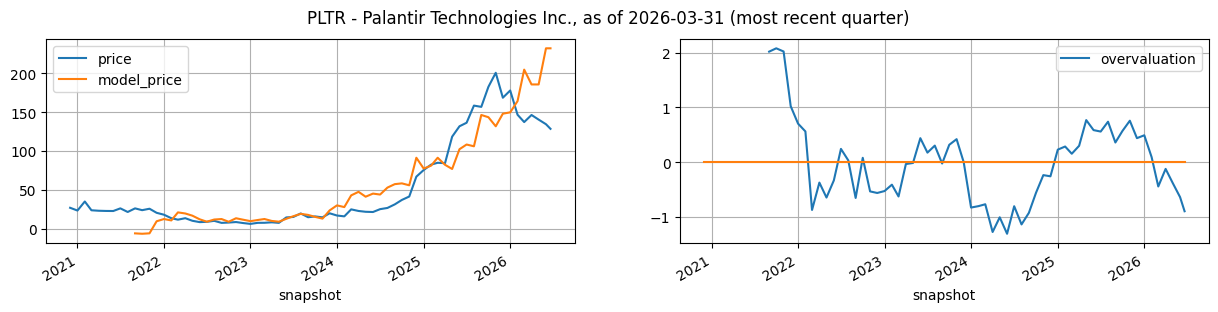

PLTR(0001321655) model_price = 46.791046 * (0.245270 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -0.130523


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,8.113960,1.523503,1.817505,146.59,0.24527,1.674419,3.509873,46.791046,-0.130523,164.100090,0.091978
2026-03-01,2025-12-31,8.900392,1.513124,2.134473,137.19,0.24527,1.735398,4.374034,46.791046,-0.130523,204.535086,-0.442804
2026-04-01,2025-12-31,8.900392,1.513124,2.134473,146.28,0.24527,1.544843,3.967301,46.791046,-0.130523,185.503627,-0.122101
2026-05-01,2025-12-31,8.900392,1.513124,2.134473,NaN,0.24527,1.544843,3.967301,46.791046,-0.130523,185.503627,NaN
2026-06-01,2026-03-31,10.199183,1.749520,2.723375,NaN,0.24527,1.544843,4.959220,46.791046,-0.130523,231.916588,NaN
2026-06-20,2026-03-31,10.199183,1.749520,2.723375,128.49,0.24527,1.544843,4.959220,46.791046,-0.130523,231.916588,-0.894959


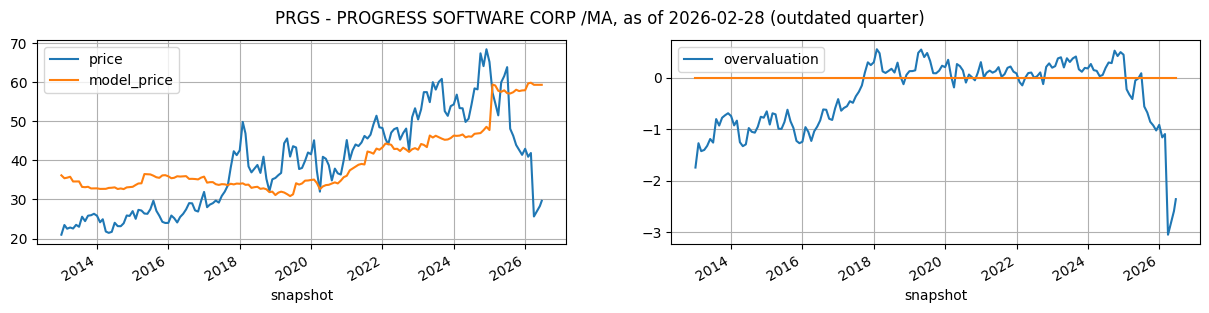

PRGS(0000876167) model_price = 12.270993 * (2.035539 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +17.744558


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-30,2.457658,1.979309,0.235187,40.92,2.035539,1.674419,3.417152,12.270993,17.744558,59.676411,-1.159841
2026-03-01,2025-11-30,2.457658,1.979309,0.235187,41.88,2.035539,1.735398,3.431494,12.270993,17.744558,59.852393,-1.095207
2026-04-01,2026-02-28,2.394774,1.895979,0.264866,25.65,2.035539,1.544843,3.387854,12.270993,17.744558,59.316895,-3.048777
2026-05-01,2026-02-28,2.394774,1.895979,0.264866,NaN,2.035539,1.544843,3.387854,12.270993,17.744558,59.316895,NaN
2026-06-01,2026-02-28,2.394774,1.895979,0.264866,NaN,2.035539,1.544843,3.387854,12.270993,17.744558,59.316895,NaN
2026-06-20,2026-02-28,2.394774,1.895979,0.264866,29.65,2.035539,1.544843,3.387854,12.270993,17.744558,59.316895,-2.358866


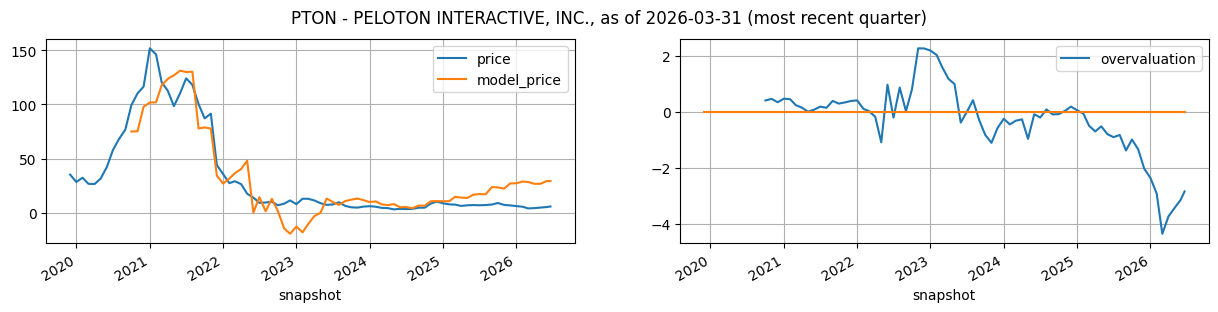

PTON(0001639825) model_price = 24.019658 * (1.454735 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -2.330862


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,2.1701,2.5171,0.3924,5.590,1.454734,1.674419,1.296861,24.019658,-2.330862,28.819305,-2.915650
2026-03-01,2025-12-31,2.1646,2.4913,0.3576,4.020,1.454734,1.735398,1.278196,24.019658,-2.330862,28.370978,-4.352595
2026-04-01,2025-12-31,2.1646,2.4913,0.3576,4.290,1.454734,1.544843,1.210054,24.019658,-2.330862,26.734226,-3.728765
2026-05-01,2025-12-31,2.1646,2.4913,0.3576,NaN,1.454734,1.544843,1.210054,24.019658,-2.330862,26.734226,NaN
2026-06-01,2026-03-31,2.0174,2.2593,0.4136,NaN,1.454734,1.544843,1.314429,24.019658,-2.330862,29.241262,NaN
2026-06-20,2026-03-31,2.0174,2.2593,0.4136,5.785,1.454734,1.544843,1.314429,24.019658,-2.330862,29.241262,-2.839462


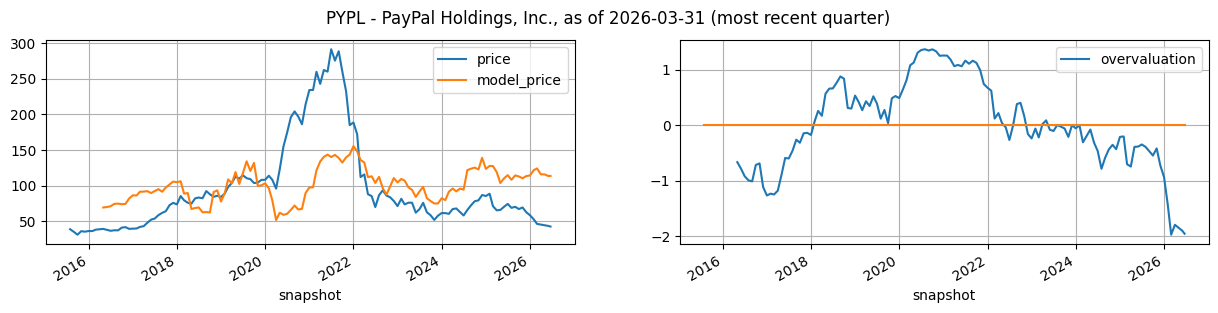

PYPL(0001633917) model_price = 6.787588 * (0.835837 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +0.379124


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,79.801,59.603,6.426,52.69,0.835837,1.674419,17.857415,6.787588,0.379124,121.587903,-1.435651
2026-03-01,2025-12-31,80.173,59.917,6.416,46.21,0.835837,1.735398,18.228838,6.787588,0.379124,124.108974,-1.974072
2026-04-01,2025-12-31,80.173,59.917,6.416,45.23,0.835837,1.544843,17.006242,6.787588,0.379124,115.810495,-1.795695
2026-05-01,2025-12-31,80.173,59.917,6.416,NaN,0.835837,1.544843,17.006242,6.787588,0.379124,115.810495,NaN
2026-06-01,2026-03-31,80.546,60.522,6.390,NaN,0.835837,1.544843,16.672843,6.787588,0.379124,113.547521,NaN
2026-06-20,2026-03-31,80.546,60.522,6.390,42.48,0.835837,1.544843,16.672843,6.787588,0.379124,113.547521,-1.955853


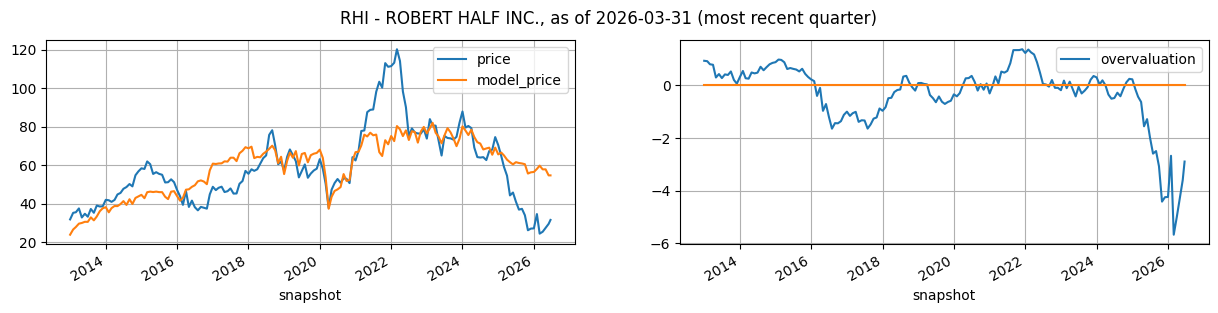

RHI(0000315213) model_price = 31.915690 * (0.814314 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +18.275401


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,2.846378,1.560286,0.292265,34.61,0.814314,1.674419,1.246933,31.91569,18.275401,58.072128,-2.676411
2026-03-01,2025-12-31,2.856276,1.580419,0.319965,24.42,0.814314,1.735398,1.300752,31.91569,18.275401,59.789812,-5.672035
2026-04-01,2025-12-31,2.856276,1.580419,0.319965,25.40,0.814314,1.544843,1.239782,31.91569,18.275401,57.843890,-5.006902
2026-05-01,2025-12-31,2.856276,1.580419,0.319965,NaN,0.814314,1.544843,1.239782,31.91569,18.275401,57.843890,NaN
2026-06-01,2026-03-31,2.703702,1.472471,0.266973,NaN,0.814314,1.544843,1.141622,31.91569,18.275401,54.711063,NaN
2026-06-20,2026-03-31,2.703702,1.472471,0.266973,31.55,0.814314,1.544843,1.141622,31.91569,18.275401,54.711063,-2.894937


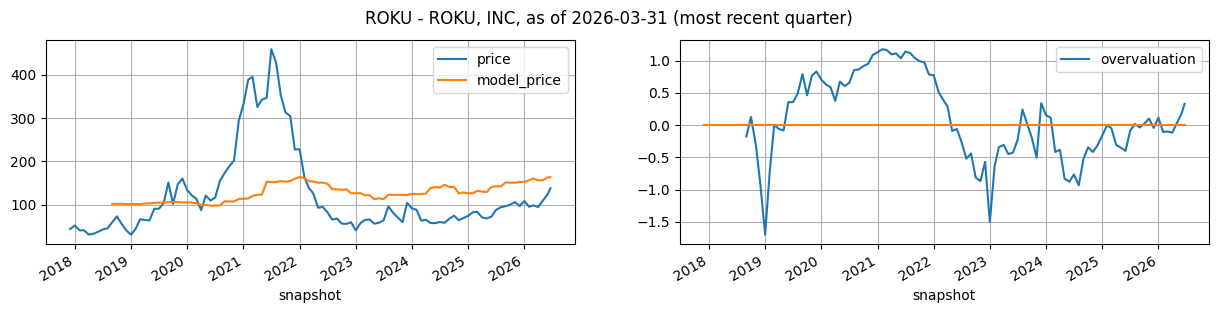

ROKU(0001428439) model_price = 46.945100 * (0.495983 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +101.404291


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,4.397285,1.772199,0.455360,95.20,0.495983,1.674419,1.171244,46.9451,101.404291,156.388464,-0.106597
2026-03-01,2025-12-31,4.433483,1.775538,0.483718,98.41,0.495983,1.735398,1.262838,46.9451,101.404291,160.688358,-0.097182
2026-04-01,2025-12-31,4.433483,1.775538,0.483718,94.62,0.495983,1.544843,1.170664,46.9451,101.404291,156.361215,-0.115910
2026-05-01,2025-12-31,4.433483,1.775538,0.483718,NaN,0.495983,1.544843,1.170664,46.9451,101.404291,156.361215,NaN
2026-06-01,2026-03-31,4.352634,1.681570,0.544126,NaN,0.495983,1.544843,1.317853,46.9451,101.404291,163.271025,NaN
2026-06-20,2026-03-31,4.352634,1.681570,0.544126,138.15,0.495983,1.544843,1.317853,46.9451,101.404291,163.271025,0.332176


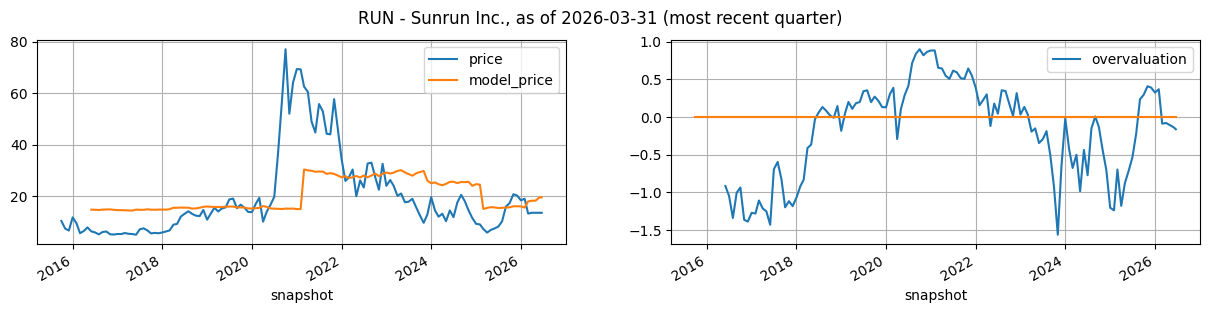

RUN(0001469367) model_price = 3.425799 * (0.949368 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +13.671265


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,22.225482,19.241580,-0.776747,19.00,0.949368,1.674419,0.557992,3.425799,13.671265,15.582833,0.369547
2026-03-01,2025-12-31,22.610596,19.478112,-0.421440,13.25,0.949368,1.735398,1.256309,3.425799,13.671265,17.975128,-0.087111
2026-04-01,2025-12-31,22.610596,19.478112,-0.421440,13.56,0.949368,1.544843,1.336616,3.425799,13.671265,18.250244,-0.077981
2026-05-01,2025-12-31,22.610596,19.478112,-0.421440,NaN,0.949368,1.544843,1.336616,3.425799,13.671265,18.250244,NaN
2026-06-01,2026-03-31,22.765093,19.424339,-0.306611,NaN,0.949368,1.544843,1.714457,3.425799,13.671265,19.544650,NaN
2026-06-20,2026-03-31,22.765093,19.424339,-0.306611,13.54,0.949368,1.544843,1.714457,3.425799,13.671265,19.544650,-0.161051


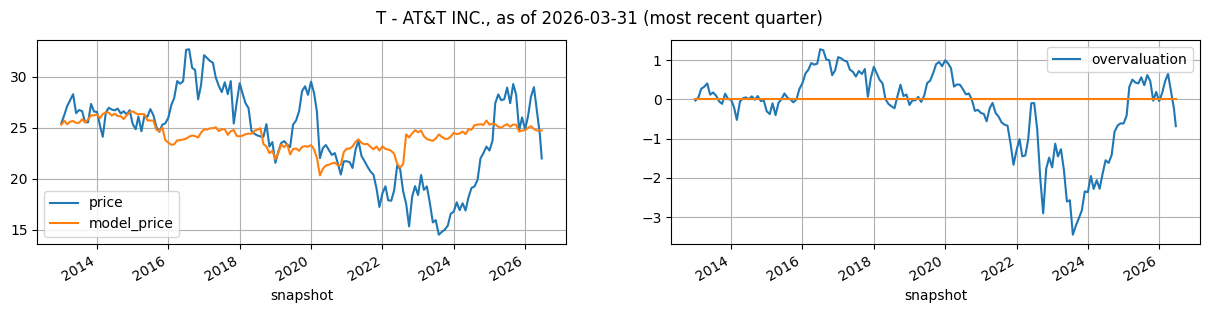

T(0000732717) model_price = 0.036170 * (0.024702 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +32.879375


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,423.213,296.458,40.860,26.210,0.024702,1.674419,-217.587144,0.03617,32.879375,25.009185,0.172309
2026-03-01,2025-12-31,420.198,293.707,40.284,28.010,0.024702,1.735398,-213.418636,0.03617,32.879375,25.159961,0.452343
2026-04-01,2025-12-31,420.198,293.707,40.284,28.990,0.024702,1.544843,-221.094924,0.03617,32.879375,24.882308,0.652311
2026-05-01,2026-03-31,421.188,295.569,38.792,NaN,0.024702,1.544843,-225.237376,0.03617,32.879375,24.732474,NaN
2026-06-01,2026-03-31,421.188,295.569,38.792,NaN,0.024702,1.544843,-225.237376,0.03617,32.879375,24.732474,NaN
2026-06-20,2026-03-31,421.188,295.569,38.792,21.995,0.024702,1.544843,-225.237376,0.03617,32.879375,24.732474,-0.680146


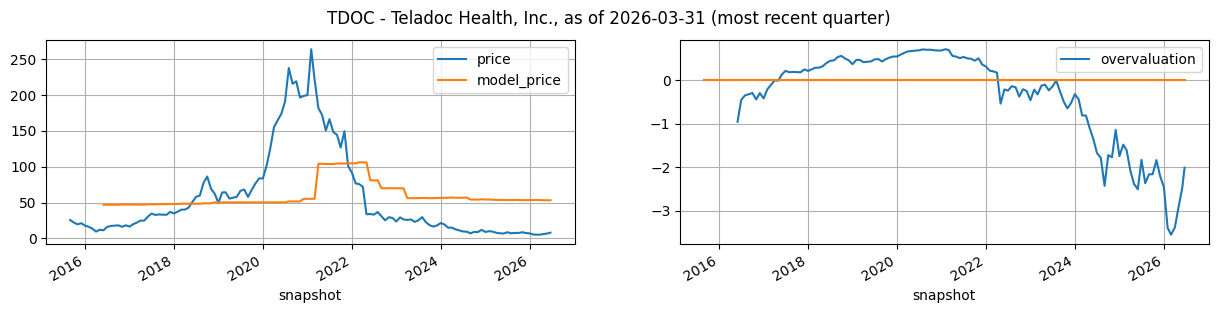

TDOC(0001477449) model_price = 3.325381 * (1.086610 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +46.540105


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,2.878547,1.486432,0.292517,5.45,1.08661,1.674419,2.131221,3.325381,46.540105,53.627225,-3.398062
2026-03-01,2025-12-31,2.858300,1.472594,0.294357,5.26,1.08661,1.735398,2.144089,3.325381,46.540105,53.670015,-3.553486
2026-04-01,2025-12-31,2.858300,1.472594,0.294357,5.45,1.08661,1.544843,2.087998,3.325381,46.540105,53.483492,-3.386788
2026-05-01,2026-03-31,2.807261,1.470945,0.287954,NaN,1.08661,1.544843,2.024296,3.325381,46.540105,53.271658,NaN
2026-06-01,2026-03-31,2.807261,1.470945,0.287954,NaN,1.08661,1.544843,2.024296,3.325381,46.540105,53.271658,NaN
2026-06-20,2026-03-31,2.807261,1.470945,0.287954,8.08,1.08661,1.544843,2.024296,3.325381,46.540105,53.271658,-2.010050


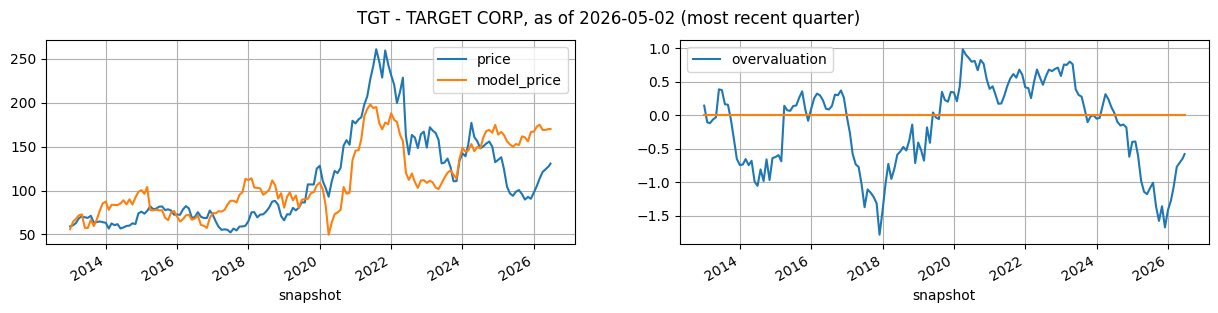

TGT(0000027419) model_price = 4.977051 * (1.475098 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -102.475502


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-11-01,59.991,44.490,6.774,105.47,1.475098,1.674419,55.345115,4.977051,-102.475502,172.979958,-1.269216
2026-03-01,2025-11-01,59.991,44.490,6.774,113.79,1.475098,1.735398,55.758182,4.977051,-102.475502,175.035813,-1.061702
2026-04-01,2026-01-31,59.490,43.325,6.562,121.20,1.475098,1.544843,54.565836,4.977051,-102.475502,169.101449,-0.770331
2026-05-01,2026-01-31,59.490,43.325,6.562,NaN,1.475098,1.544843,54.565836,4.977051,-102.475502,169.101449,NaN
2026-06-01,2026-05-02,58.010,41.615,7.003,NaN,1.475098,1.544843,54.773967,4.977051,-102.475502,170.137328,NaN
2026-06-20,2026-05-02,58.010,41.615,7.003,130.71,1.475098,1.544843,54.773967,4.977051,-102.475502,170.137328,-0.579655


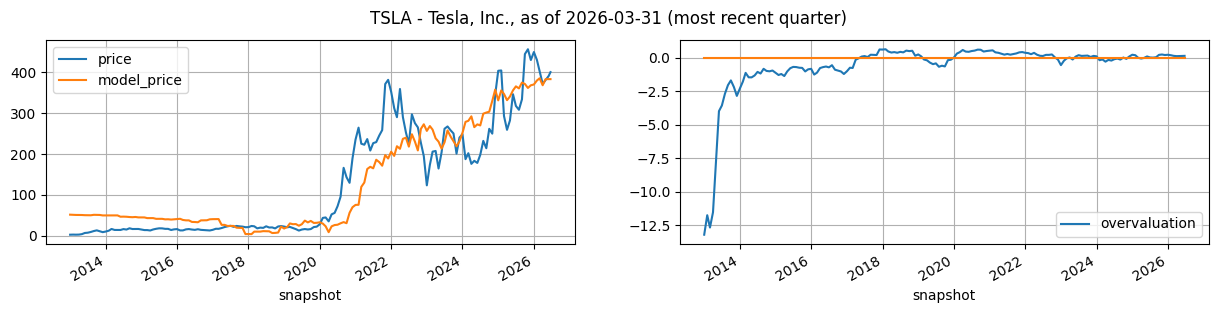

TSLA(0001318605) model_price = 6.071212 * (0.617863 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +51.105329


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-31,137.806,55.669,14.747,430.41,0.617863,1.674419,54.168957,6.071212,51.105329,379.976540,0.177149
2026-03-01,2025-12-31,137.806,55.669,14.747,402.51,0.617863,1.735398,55.068204,6.071212,51.105329,385.436058,0.131357
2026-04-01,2025-12-31,137.806,55.669,14.747,371.75,0.617863,1.544843,52.258100,6.071212,51.105329,368.375324,0.110934
2026-05-01,2026-03-31,143.724,59.608,16.528,NaN,0.617863,1.544843,54.726983,6.071212,51.105329,383.364430,NaN
2026-06-01,2026-03-31,143.724,59.608,16.528,NaN,0.617863,1.544843,54.726983,6.071212,51.105329,383.364430,NaN
2026-06-20,2026-03-31,143.724,59.608,16.528,400.50,0.617863,1.544843,54.726983,6.071212,51.105329,383.364430,0.131582


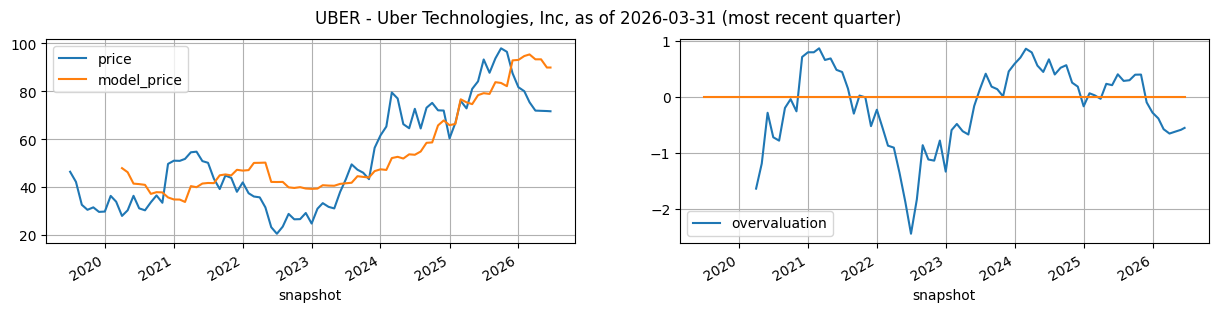

UBER(0001543151) model_price = 1.062729 * (1.509503 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +14.585595


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,63.344,35.210,8.966,80.05,1.509503,1.674419,75.420810,1.062729,14.585595,94.737463,-0.385402
2026-03-01,2025-12-31,61.802,34.761,10.099,75.42,1.509503,1.735398,76.055094,1.062729,14.585595,95.411534,-0.577675
2026-04-01,2025-12-31,61.802,34.761,10.099,71.93,1.509503,1.544843,74.130686,1.062729,14.585595,93.366411,-0.655320
2026-05-01,2025-12-31,61.802,34.761,10.099,NaN,1.509503,1.544843,74.130686,1.062729,14.585595,93.366411,NaN
2026-06-01,2026-03-31,59.885,35.134,10.126,NaN,1.509503,1.544843,70.905679,1.062729,14.585595,89.939103,NaN
2026-06-20,2026-03-31,59.885,35.134,10.126,71.66,1.509503,1.544843,70.905679,1.062729,14.585595,89.939103,-0.554137


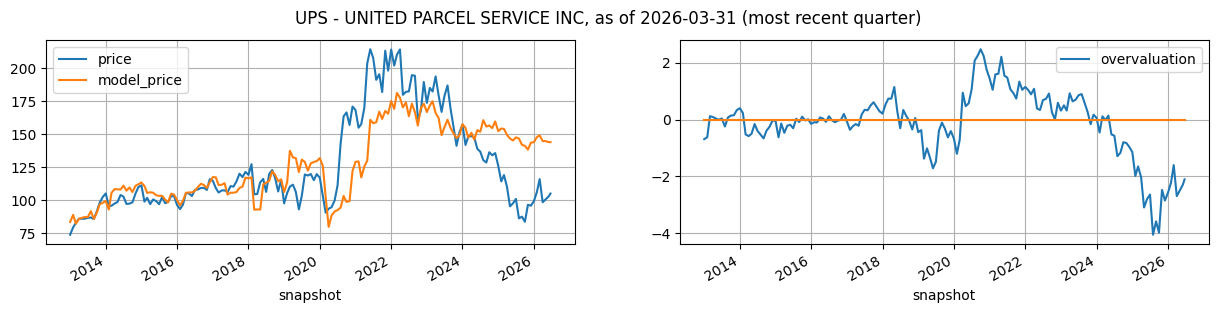

UPS(0001090727) model_price = 2.696978 * (0.752857 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +114.586912


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,71.392,55.569,8.463,106.22,0.752857,1.674419,12.349546,2.696978,114.586912,147.893370,-2.222853
2026-03-01,2025-12-31,73.090,56.863,8.450,115.96,0.752857,1.735398,12.827396,2.696978,114.586912,149.182120,-1.600662
2026-04-01,2025-12-31,73.090,56.863,8.450,98.38,0.752857,1.544843,11.217212,2.696978,114.586912,144.839490,-2.692663
2026-05-01,2025-12-31,73.090,56.863,8.450,NaN,0.752857,1.544843,11.217212,2.696978,114.586912,144.839490,NaN
2026-06-01,2026-03-31,71.809,56.046,8.356,NaN,0.752857,1.544843,10.924588,2.696978,114.586912,144.050288,NaN
2026-06-20,2026-03-31,71.809,56.046,8.356,105.00,0.752857,1.544843,10.924588,2.696978,114.586912,144.050288,-2.102786


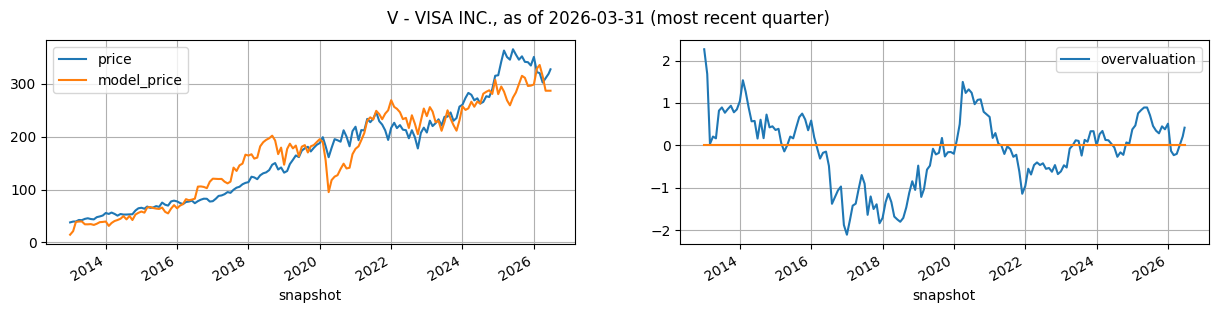

V(0001403161) model_price = 4.557605 * (1.174051 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -111.363950


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-12-31,96.814,58.037,24.443,321.83,1.174052,1.674419,96.555458,4.557605,-111.36395,328.697655,-0.131340
2026-03-01,2025-12-31,96.814,58.037,24.443,320.14,1.174052,1.735398,98.045950,4.557605,-111.36395,335.490730,-0.231767
2026-04-01,2025-12-31,96.814,58.037,24.443,302.24,1.174052,1.544843,93.388232,4.557605,-111.36395,314.262694,-0.200928
2026-05-01,2026-03-31,95.049,59.388,22.756,NaN,1.174052,1.544843,87.358880,4.557605,-111.36395,286.783292,NaN
2026-06-01,2026-03-31,95.049,59.388,22.756,NaN,1.174052,1.544843,87.358880,4.557605,-111.36395,286.783292,NaN
2026-06-20,2026-03-31,95.049,59.388,22.756,327.25,1.174052,1.544843,87.358880,4.557605,-111.36395,286.783292,0.415864


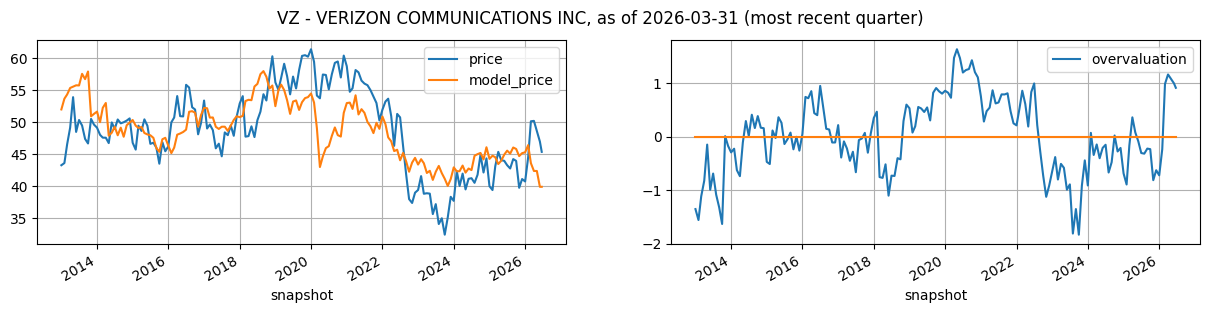

VZ(0000732712) model_price = 0.172497 * (0.006419 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +83.519859


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,388.331,281.986,38.455,44.52,0.006419,1.674419,-215.103505,0.172497,83.519859,46.415087,-0.231873
2026-03-01,2025-12-31,404.258,298.517,37.137,50.14,0.006419,1.735398,-231.474603,0.172497,83.519859,43.591117,0.985054
2026-04-01,2025-12-31,404.258,298.517,37.137,50.20,0.006419,1.544843,-238.551217,0.172497,83.519859,42.370421,1.163229
2026-05-01,2025-12-31,404.258,298.517,37.137,NaN,0.006419,1.544843,-238.551217,0.172497,83.519859,42.370421,NaN
2026-06-01,2026-03-31,417.882,313.260,37.339,NaN,0.006419,1.544843,-252.894706,0.172497,83.519859,39.896208,NaN
2026-06-20,2026-03-31,417.882,313.260,37.339,45.36,0.006419,1.544843,-252.894706,0.172497,83.519859,39.896208,0.913674


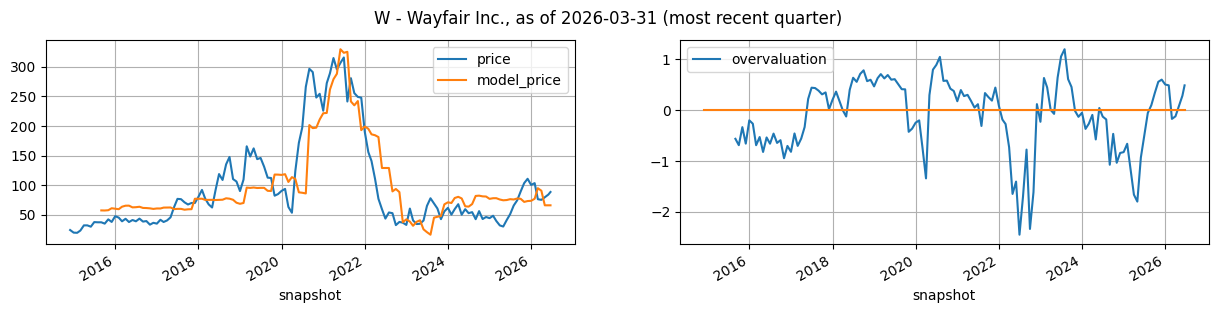

W(0001616707) model_price = 41.889013 * (2.045022 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +22.011542


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-09-30,3.116,5.884,0.494,103.49,2.045022,1.674419,1.315453,41.889013,22.011542,77.114549,0.489020
2026-03-01,2025-12-31,3.440,6.222,0.534,76.33,2.045022,1.735398,1.739579,41.889013,22.011542,94.880785,-0.170942
2026-04-01,2025-12-31,3.440,6.222,0.534,75.21,2.045022,1.544843,1.637823,41.889013,22.011542,90.618328,-0.120356
2026-05-01,2026-03-31,2.870,5.712,0.578,NaN,2.045022,1.544843,1.050133,41.889013,22.011542,66.000592,NaN
2026-06-01,2026-03-31,2.870,5.712,0.578,NaN,2.045022,1.544843,1.050133,41.889013,22.011542,66.000592,NaN
2026-06-20,2026-03-31,2.870,5.712,0.578,88.51,2.045022,1.544843,1.050133,41.889013,22.011542,66.000592,0.488298


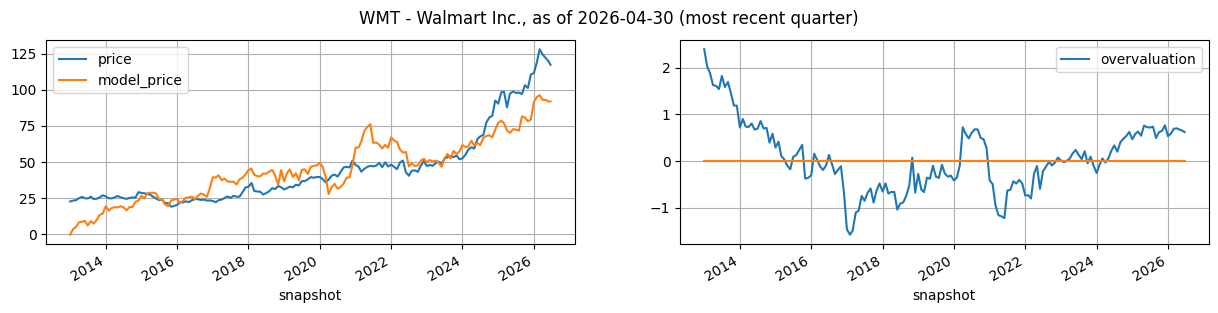

WMT(0000104169) model_price = 0.484559 * (1.819275 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -99.435028


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-10-31,288.655,192.561,40.977,119.14,1.819275,1.674419,401.194618,0.484559,-99.435028,94.967247,0.591631
2026-03-01,2025-10-31,288.655,192.561,40.977,127.95,1.819275,1.735398,403.693326,0.484559,-99.435028,96.178017,0.693372
2026-04-01,2026-01-31,284.668,185.051,41.565,124.28,1.819275,1.544843,397.049901,0.484559,-99.435028,92.958889,0.701671
2026-05-01,2026-01-31,284.668,185.051,41.565,NaN,1.819275,1.544843,397.049901,0.484559,-99.435028,92.958889,NaN
2026-06-01,2026-04-30,289.607,195.277,40.892,NaN,1.819275,1.544843,394.769622,0.484559,-99.435028,91.853961,NaN
2026-06-20,2026-04-30,289.607,195.277,40.892,117.18,1.819275,1.544843,394.769622,0.484559,-99.435028,91.853961,0.621278


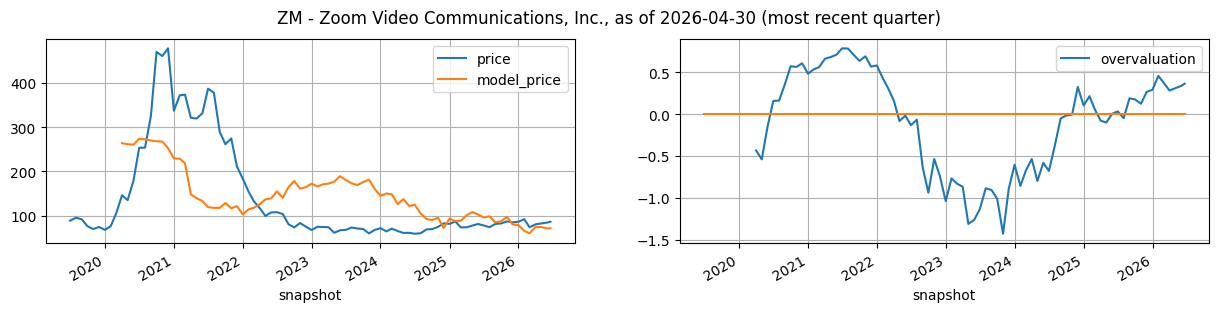

ZM(0001585521) model_price = -38.022869 * (0.334446 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +261.569125


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-02-01,2025-10-31,11.390811,2.103971,2.059093,92.10,0.334446,1.674419,5.153427,-38.022869,261.569125,65.621058,0.456177
2026-03-01,2026-01-31,11.960416,2.152158,1.989048,73.94,0.334446,1.735398,5.299746,-38.022869,261.569125,60.057581,0.374879
2026-04-01,2026-01-31,11.960416,2.152158,1.989048,80.39,0.334446,1.544843,4.920724,-38.022869,261.569125,74.469069,0.281887
2026-05-01,2026-01-31,11.960416,2.152158,1.989048,NaN,0.334446,1.544843,4.920724,-38.022869,261.569125,74.469069,NaN
2026-06-01,2026-04-30,12.162017,2.190869,2.021397,NaN,0.334446,1.544843,4.999412,-38.022869,261.569125,71.477133,NaN
2026-06-20,2026-04-30,12.162017,2.190869,2.021397,86.41,0.334446,1.544843,4.999412,-38.022869,261.569125,71.477133,0.362705


In [21]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PRGS","PTON","PYPL",
                "RHI","ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","W","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group

    # Get a ticker fallback name if recent price data is available
    try:
        name = recent_prices.loc[ticker]['name']
    except:
        name = ""

    # Get the default name from the SEC tickers dataset
    try:
        name = tickers.loc[cik]['name']
    except:
        pass

    df = df.reset_index().set_index('snapshot')

    quarters_since_last_report = (datetime.today() - df['date'].max()) / timedelta(days=7) / 13
    caption = f"{ticker} - {name}"
    caption += f", as of {df['date'].max():%Y-%m-%d} ({"most recent" if quarters_since_last_report < 1 else "outdated"} quarter)"
    
    # Display two plots side-by-side: of the price & fair-price and of the scaled overvaluation estimate.
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(caption)
    fig.set_size_inches(15,5)
    plot_df = df[['price','model_price','overvaluation']].interpolate(limit_area='inside')
    plot_df[['price','model_price']].plot(ax=ax1, grid=True, legend=True)
    plot_df['overvaluation'].plot(ax=ax2, grid=True, legend=True, figsize=(15,3))
    pd.Series([0.0]*len(df.index),index=df.index).plot(ax=ax2,grid=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print("{}({}) model_price = {:.6f} * ({:.6f} * Assets - Liabilities + cashmul * NetCashOperating_ttm) {}{:.6f}".format(
        ticker, cik, df['hype'].mean(), df['asmul'].mean(),
        "+" if df['bias'].mean() >= 0 else "", df['bias'].mean()
    ))

    # Display a few most recent records from the result set
    display(df.drop(columns=['cik','ticker']).tail(6))

for i in result[result.index.isin(sample_tickers, level='ticker')].groupby(by=['ticker','cik']):
    plot_ticker(i)
    display(HTML("<hr>"))

The model has a lot of room for improvement. It is easy to notice that for some stocks it produces anomalies that should be investigated further. They are probably caused by shifting corporate accounting practices over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.

The biggest advantage of the model, however, is that its results are completely explainable.

All overvaluation sequences are scaled, therefore directly comparable, so we can plot them together, as shown below. An interesting observaton here is, that the magnitudes of overvaluation and undervaluation are not symmetrical. I.e., when stocks are undervalued, they tend to be undervalued slightly deeper, than when they are overvalued.

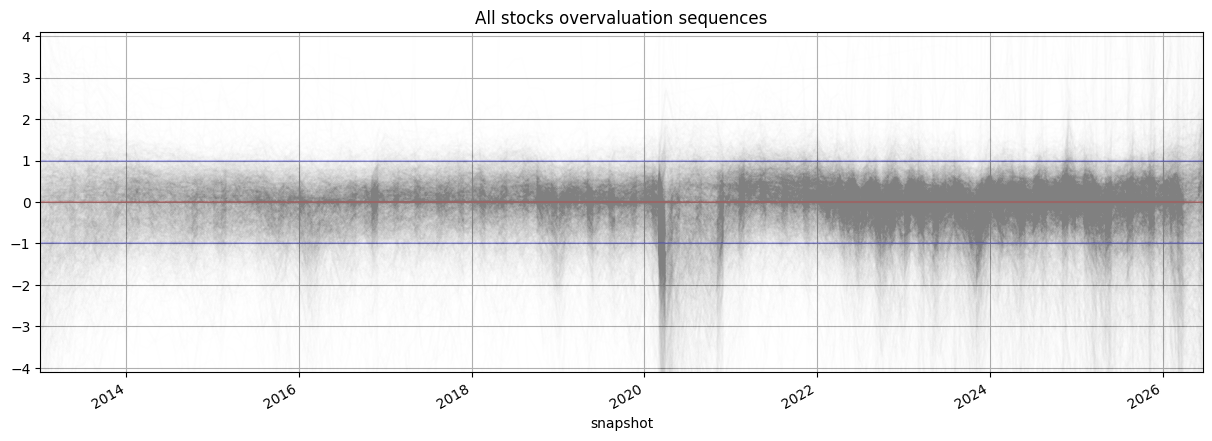

CPU times: user 6.97 s, sys: 47.5 ms, total: 7.01 s
Wall time: 6.98 s


In [22]:
%%time
def plot_overvaluations(df):
    overvaluations = pd.pivot_table(df, index='snapshot', columns='ticker', values='overvaluation', dropna=False).interpolate(limit_area='inside').dropna(how='all')
    x_lim = sorted(overvaluations.index.to_frame().agg(['min','max']).iloc[:,0].to_list())
    horizontal_ticks = [-1,0,1]
    horizontal_lines = pd.DataFrame([horizontal_ticks]*len(overvaluations.index), index=overvaluations.index, columns=horizontal_ticks)
    ax = overvaluations.plot(figsize=(15,5), title='All stocks overvaluation sequences', xlim=x_lim, ylim=(-4.1,4.1), grid=True, legend=False, c='grey', alpha=0.005 )
    horizontal_lines[0].plot(ax=ax, grid=True, c='red', alpha=0.2, legend=False)
    horizontal_lines.drop(columns=[0]).plot(ax=ax, grid=True, c='blue', alpha=0.2, legend=False)
    return ax
plot_overvaluations(result)
plt.show()

In [23]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.